# Final full-experiment pipeline

This is the submission-ready pipeline used for the final PHAS0077 experiments. It freezes the train/validation/test split and model checkpoints, evaluates the Baseline ResNet-18, Monte Carlo Dropout and Temperature Scaling configurations, runs the fixed 7×7 regional occlusion experiment on the final 100-image composite-uncertainty cohort, performs the MC Dropout pass-count stability check, computes Score-CAM/uncertainty spatial-overlap metrics, and exports the report-level tables and representative-case files.

**Recommended use:** configure the dataset location in the data-setup cell below, then run the notebook from top to bottom. The complete experiment is computationally expensive; set `MAX_TARGET_SAMPLES = 5` for a quick pipeline check before a full run.


In [1]:
# 0. Imports and global config


import os
import copy
import json
import time
import random
import shutil
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models


In [2]:
# 1. Portable dataset setup


# The notebook works in Google Colab or a local Python/Jupyter environment.
# Set CXR_DATA_ROOT to the extracted COVID-19_Radiography_Dataset directory.

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    drive.mount("/content/drive")

default_data_root = (
    Path("/content/data/COVID-19_Radiography_Dataset")
    if IN_COLAB
    else Path("./data/COVID-19_Radiography_Dataset")
)
default_archive_path = (
    Path("/content/drive/MyDrive/archive.zip")
    if IN_COLAB
    else Path("./archive.zip")
)

DATA_ROOT = Path(os.environ.get("CXR_DATA_ROOT", str(default_data_root)))
ARCHIVE_PATH = Path(os.environ.get("CXR_ARCHIVE_PATH", str(default_archive_path)))

if not DATA_ROOT.exists():
    if ARCHIVE_PATH.exists():
        DATA_ROOT.parent.mkdir(parents=True, exist_ok=True)
        print(f"Extracting dataset archive: {ARCHIVE_PATH}")
        shutil.unpack_archive(str(ARCHIVE_PATH), str(DATA_ROOT.parent))
    else:
        raise FileNotFoundError(
            "Dataset not found. Set the CXR_DATA_ROOT environment variable to the "
            "extracted COVID-19_Radiography_Dataset directory, or set "
            "CXR_ARCHIVE_PATH to the dataset archive."
        )

print("DATA_ROOT:", DATA_ROOT)


Mounted at /content/drive
Extracting dataset archive: /content/drive/MyDrive/archive.zip
DATA_ROOT: /content/data/COVID-19_Radiography_Dataset


In [3]:
# 2. Final experiment settings


CLASS_NAMES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0  # More stable in Colab than multiprocessing workers.

# Persistent project folder. It uses Google Drive when available.
DEFAULT_PROJECT_DIR = Path("/content/drive/MyDrive/PHAS0077_final_experiment")
PROJECT_DIR = DEFAULT_PROJECT_DIR if Path("/content/drive/MyDrive").exists() else Path("./PHAS0077_final_experiment")
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
SPLIT_DIR = PROJECT_DIR / "fixed_splits"
OUTPUT_DIR = PROJECT_DIR / "outputs_top100_composite"
PARTS_DIR = OUTPUT_DIR / "occlusion_parts"
SCORECAM_PARTS_DIR = OUTPUT_DIR / "scorecam_parts"

for folder in [PROJECT_DIR, CHECKPOINT_DIR, SPLIT_DIR, OUTPUT_DIR, PARTS_DIR, SCORECAM_PARTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

BASELINE_CKPT = CHECKPOINT_DIR / "baseline_resnet18_seed42_final.pth"
MC_DROPOUT_CKPT = CHECKPOINT_DIR / "mc_dropout_resnet18_p030_seed42_final.pth"
LEGACY_BASELINE_CKPT = Path("best_resnet18_cxr.pth")
LEGACY_MC_DROPOUT_CKPT = Path("best_resnet18_mc_dropout_cxr.pth")

# Training settings
BASELINE_EPOCHS = 5
BASELINE_LR = 1e-4
MC_DROPOUT_EPOCHS = 5
MC_DROPOUT_LR = 1e-4
MC_DROPOUT_P = 0.30

# MC Dropout settings
N_MC_EVAL = 30
N_MC_OCCLUSION = 30
MC_VARIANT_BATCH_SIZE = 50  # original + 49 masked variants fit in one batch on most GPUs
MC_STABILITY_PASS_LIST = [10, 20, 30, 50]
RUN_MC_STABILITY_CHECK = True
MC_STABILITY_SAMPLE_COUNT = 10

# Full experiment settings
GRID_SIZE = 7
MASK_FILL_VALUE = 0.0
TARGET_SAMPLE_COUNT = 100
MAX_TARGET_SAMPLES = None  # None = full fixed cohort; set 5 only for a quick code test.
REQUIRE_EXACT_TARGET_COUNT = False
OCCLUSION_CHUNK_SIZE = 10
RUN_FULL_OCCLUSION = True

# Score-CAM overlap settings
RUN_SCORECAM_OVERLAP = True
SCORECAM_MAX_CHANNELS = 64
SCORECAM_CHANNEL_BATCH_SIZE = 16
SCORECAM_TOP_K = 5
UQ_TOP_K = 5
SCORECAM_CHUNK_SIZE = 10

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("BASELINE_CKPT:", BASELINE_CKPT)
print("MC_DROPOUT_CKPT:", MC_DROPOUT_CKPT)


PROJECT_DIR: /content/drive/MyDrive/PHAS0077_final_experiment
OUTPUT_DIR: /content/drive/MyDrive/PHAS0077_final_experiment/outputs_top100_composite
BASELINE_CKPT: /content/drive/MyDrive/PHAS0077_final_experiment/checkpoints/baseline_resnet18_seed42_final.pth
MC_DROPOUT_CKPT: /content/drive/MyDrive/PHAS0077_final_experiment/checkpoints/mc_dropout_resnet18_p030_seed42_final.pth


In [4]:
# Reproducibility setting


def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_global_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("SEED =", SEED)


SEED = 42


In [5]:
# 3. Load file paths and freeze train/validation/test splits


def collect_image_paths(data_root, class_names):
    rows = []
    data_root = Path(data_root)

    for cls in class_names:
        img_dir = data_root / cls / "images"
        if not img_dir.exists():
            raise FileNotFoundError(f"Cannot find image folder: {img_dir}")

        for fname in sorted(os.listdir(img_dir)):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                rows.append({
                    "filepath": str(img_dir / fname),
                    "label_name": cls,
                    "label": CLASS_TO_IDX[cls]
                })

    out = pd.DataFrame(rows).sort_values("filepath").reset_index(drop=True)
    out["dataset_index"] = np.arange(len(out), dtype=int)
    return out


def validate_split_df(split_df, split_name):
    required = {"filepath", "label_name", "label", "dataset_index"}
    missing = required.difference(split_df.columns)
    if missing:
        raise ValueError(f"{split_name} split is missing columns: {sorted(missing)}")
    missing_files = split_df.loc[~split_df["filepath"].map(os.path.exists), "filepath"]
    if len(missing_files) > 0:
        raise FileNotFoundError(
            f"{split_name} contains {len(missing_files)} missing image paths. "
            "Delete the fixed split CSV files and recreate them after checking DATA_ROOT."
        )


def load_or_create_fixed_splits(df, split_dir, seed):
    train_csv = split_dir / "train_split.csv"
    val_csv = split_dir / "validation_split.csv"
    test_csv = split_dir / "test_split.csv"

    if train_csv.exists() and val_csv.exists() and test_csv.exists():
        print("Loading frozen dataset splits from:", split_dir)
        train_df = pd.read_csv(train_csv)
        val_df = pd.read_csv(val_csv)
        test_df = pd.read_csv(test_csv)
    else:
        print("Creating and freezing dataset splits...")
        train_df, temp_df = train_test_split(
            df,
            test_size=0.30,
            stratify=df["label"],
            random_state=seed
        )
        val_df, test_df = train_test_split(
            temp_df,
            test_size=0.50,
            stratify=temp_df["label"],
            random_state=seed
        )
        train_df = train_df.sort_values("dataset_index").reset_index(drop=True)
        val_df = val_df.sort_values("dataset_index").reset_index(drop=True)
        test_df = test_df.sort_values("dataset_index").reset_index(drop=True)
        train_df.to_csv(train_csv, index=False)
        val_df.to_csv(val_csv, index=False)
        test_df.to_csv(test_csv, index=False)

    for split_name, split_df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
        validate_split_df(split_df, split_name)
        split_df["label"] = split_df["label"].astype(int)
        split_df["dataset_index"] = split_df["dataset_index"].astype(int)

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True)
    )


df = collect_image_paths(DATA_ROOT, CLASS_NAMES)
train_df, val_df, test_df = load_or_create_fixed_splits(df, SPLIT_DIR, SEED)

print("Total images:", len(df))
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))
print("\nFrozen test class counts:")
print(test_df["label_name"].value_counts().reindex(CLASS_NAMES))


Loading frozen dataset splits from: /content/drive/MyDrive/PHAS0077_final_experiment/fixed_splits
Total images: 21165
Train size: 14815
Validation size: 3175
Test size: 3175

Frozen test class counts:
label_name
COVID               542
Lung_Opacity        902
Normal             1529
Viral Pneumonia     202
Name: count, dtype: int64


In [6]:
# 4. Dataset, transforms, dataloaders


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

class CXRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, int(row["label"])


train_dataset = CXRDataset(train_df, transform=train_transform)
val_dataset = CXRDataset(val_df, transform=eval_transform)
test_dataset = CXRDataset(test_df, transform=eval_transform)

class_sample_count = train_df["label"].value_counts().sort_index().values
class_weights = 1.0 / class_sample_count
sample_weights = train_df["label"].map(lambda x: class_weights[int(x)]).values

sampler_generator = torch.Generator()
sampler_generator.manual_seed(SEED)

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
    generator=sampler_generator
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Class counts:", class_sample_count)
print("Class weights:", class_weights)


Class counts: [2531 4208 7134  942]
Class weights: [0.0003951  0.00023764 0.00014017 0.00106157]


In [7]:

# 5. Model builders


def build_resnet18(num_classes=NUM_CLASSES, pretrained=True):
    """Build ResNet-18 for single-channel CXR classification."""
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet18(weights=weights)

    # Change first conv layer from 3-channel RGB to 1-channel grayscale.
    old_conv = model.conv1
    model.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )

    # Initialise single-channel conv using the mean of RGB weights.
    if pretrained:
        with torch.no_grad():
            model.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    return model


def build_mc_dropout_from_baseline(baseline_model, dropout_p=0.30):
    """
    Copy the trained baseline model and insert Dropout before the final Linear layer.
    This preserves the baseline weights, then allows optional fine-tuning.
    """
    mc_model = copy.deepcopy(baseline_model)

    if isinstance(mc_model.fc, nn.Linear):
        old_fc = mc_model.fc
        mc_model.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            old_fc
        )
    elif isinstance(mc_model.fc, nn.Sequential):
        print("The model already has a Sequential classifier head.")
    else:
        raise TypeError(f"Unsupported fc layer type: {type(mc_model.fc)}")

    return mc_model

In [8]:
# 6. Training, checkpoint and evaluation helpers


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate_loss_acc(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def collect_logits_and_labels(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        all_logits.append(model(images).detach().cpu())
        all_labels.append(labels.detach().cpu())

    return torch.cat(all_logits).numpy(), torch.cat(all_labels).numpy()


def load_model_checkpoint(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint
    model.load_state_dict(state_dict)
    return model


def fit_model_with_checkpoint(
    model,
    train_loader,
    val_loader,
    checkpoint_path,
    epochs,
    lr,
    device,
    description="model",
    extra_metadata=None
):
    checkpoint_path = Path(checkpoint_path)
    criterion = nn.CrossEntropyLoss()
    model = model.to(device)

    if checkpoint_path.exists():
        print(f"Loading frozen {description} checkpoint: {checkpoint_path}")
        return load_model_checkpoint(model, checkpoint_path, device)

    print(f"No frozen checkpoint found. Training {description}...")
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )
    best_val_loss = float("inf")

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_loss_acc(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            metadata = {
                "description": description,
                "epoch": epoch + 1,
                "best_validation_loss": float(best_val_loss),
                "seed": SEED,
                "class_names": CLASS_NAMES,
                "image_size": IMG_SIZE,
                "learning_rate": lr,
            }
            if extra_metadata:
                metadata.update(extra_metadata)
            torch.save({"model_state_dict": model.state_dict(), "metadata": metadata}, checkpoint_path)

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    print(f"Loading best frozen {description} checkpoint.")
    return load_model_checkpoint(model, checkpoint_path, device)


In [9]:
# Final global config and experiment manifest


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Copy legacy checkpoints once so previous training is not lost.
if not BASELINE_CKPT.exists() and LEGACY_BASELINE_CKPT.exists():
    shutil.copy2(LEGACY_BASELINE_CKPT, BASELINE_CKPT)
    print("Copied legacy baseline checkpoint to:", BASELINE_CKPT)
if not MC_DROPOUT_CKPT.exists() and LEGACY_MC_DROPOUT_CKPT.exists():
    shutil.copy2(LEGACY_MC_DROPOUT_CKPT, MC_DROPOUT_CKPT)
    print("Copied legacy MC Dropout checkpoint to:", MC_DROPOUT_CKPT)

experiment_config = {
    "seed": SEED,
    "device": str(DEVICE),
    "data_root": str(DATA_ROOT),
    "class_names": CLASS_NAMES,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "baseline_checkpoint": str(BASELINE_CKPT),
    "mc_dropout_checkpoint": str(MC_DROPOUT_CKPT),
    "baseline_epochs": BASELINE_EPOCHS,
    "baseline_lr": BASELINE_LR,
    "mc_dropout_epochs": MC_DROPOUT_EPOCHS,
    "mc_dropout_lr": MC_DROPOUT_LR,
    "mc_dropout_p": MC_DROPOUT_P,
    "n_mc_eval": N_MC_EVAL,
    "n_mc_occlusion": N_MC_OCCLUSION,
    "grid_size": GRID_SIZE,
    "mask_fill_value": MASK_FILL_VALUE,
    "target_sample_count": TARGET_SAMPLE_COUNT,
    "scorecam_top_k": SCORECAM_TOP_K,
    "uq_top_k": UQ_TOP_K,
}

with open(OUTPUT_DIR / "experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)

print("SEED:", SEED)
print("DEVICE:", DEVICE)


SEED: 42
DEVICE: cuda


In [10]:
# 7. Train/load and freeze final Baseline ResNet


baseline_model = build_resnet18(num_classes=NUM_CLASSES, pretrained=True)
baseline_model = fit_model_with_checkpoint(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    checkpoint_path=BASELINE_CKPT,
    epochs=BASELINE_EPOCHS,
    lr=BASELINE_LR,
    device=DEVICE,
    description="Final Baseline ResNet",
    extra_metadata={"test_split_csv": str(SPLIT_DIR / "test_split.csv")}
)

baseline_model.eval()
print("Final baseline classifier:", baseline_model.fc)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


Loading frozen Final Baseline ResNet checkpoint: /content/drive/MyDrive/PHAS0077_final_experiment/checkpoints/baseline_resnet18_seed42_final.pth
Final baseline classifier: Linear(in_features=512, out_features=4, bias=True)


In [11]:
# 8. Train/load ResNet + MC Dropout


mc_model = build_mc_dropout_from_baseline(baseline_model, dropout_p=MC_DROPOUT_P)
mc_model = fit_model_with_checkpoint(
    model=mc_model,
    train_loader=train_loader,
    val_loader=val_loader,
    checkpoint_path=MC_DROPOUT_CKPT,
    epochs=MC_DROPOUT_EPOCHS,
    lr=MC_DROPOUT_LR,
    device=DEVICE,
    description="ResNet + MC Dropout",
    extra_metadata={
        "dropout_probability": MC_DROPOUT_P,
        "initialised_from_baseline": str(BASELINE_CKPT),
        "note": "This model is fine-tuned after adding dropout. A deterministic MC-model control is evaluated below."
    }
)

mc_model.eval()
print("MC Dropout classifier:", mc_model.fc)


Loading frozen ResNet + MC Dropout checkpoint: /content/drive/MyDrive/PHAS0077_final_experiment/checkpoints/mc_dropout_resnet18_p030_seed42_final.pth
MC Dropout classifier: Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=4, bias=True)
)


In [12]:
# 9. Probability, calibration and uncertainty helpers


METHOD_BASELINE = "baseline_resnet"
METHOD_MC = "resnet_mc_dropout"
METHOD_TS = "resnet_temperature_scaling"
METHOD_MC_DET = "mc_model_deterministic_control"

METHOD_DISPLAY = {
    METHOD_BASELINE: "Baseline ResNet",
    METHOD_MC: "ResNet + MC Dropout",
    METHOD_TS: "ResNet + Temperature Scaling",
    METHOD_MC_DET: "MC Model (Dropout Off)"
}

MAIN_METHODS = [METHOD_BASELINE, METHOD_MC, METHOD_TS]


def softmax_np(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)


def entropy_np(probs, eps=1e-12):
    return -np.sum(probs * np.log(probs + eps), axis=1)


def margin_np(probs):
    sorted_probs = np.sort(probs, axis=1)
    return sorted_probs[:, -1] - sorted_probs[:, -2]


def one_hot(labels, num_classes=NUM_CLASSES):
    return np.eye(num_classes)[labels]


def brier_score_multiclass(y_true, probs):
    y_oh = one_hot(y_true, probs.shape[1])
    return float(np.mean(np.sum((probs - y_oh) ** 2, axis=1)))


def nll_score(y_true, probs, eps=1e-12):
    return float(-np.mean(np.log(probs[np.arange(len(y_true)), y_true] + eps)))


def expected_calibration_error(y_true, probs, n_bins=10):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correctness = (predictions == y_true).astype(float)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []

    for i in range(n_bins):
        left, right = bin_edges[i], bin_edges[i + 1]
        mask = (confidences >= left) & (confidences <= right) if i == 0 else (confidences > left) & (confidences <= right)
        n_bin = int(mask.sum())
        prop = n_bin / len(y_true)
        if n_bin > 0:
            bin_acc = float(correctness[mask].mean())
            bin_conf = float(confidences[mask].mean())
            gap = abs(bin_acc - bin_conf)
            ece += prop * gap
        else:
            bin_acc = bin_conf = gap = np.nan
        rows.append({
            "bin": i + 1, "bin_left": left, "bin_right": right,
            "n": n_bin, "accuracy": bin_acc, "confidence": bin_conf,
            "gap": gap, "proportion": prop
        })
    return float(ece), pd.DataFrame(rows)


def assign_case_type(row):
    if row["correct"] and row["confidence"] >= HIGH_CONF_THRESHOLD:
        return "Correct + high confidence"
    if (not row["correct"]) and row["confidence"] >= HIGH_CONF_THRESHOLD:
        return "Overconfident failure"
    if row["correct"] and row["entropy"] >= UNCERTAIN_ENTROPY_THRESHOLD:
        return "Correct but uncertain"
    if (not row["correct"]) and row["entropy"] >= UNCERTAIN_ENTROPY_THRESHOLD:
        return "Incorrect but uncertain"
    return "Other correct" if row["correct"] else "Other incorrect"


def build_prediction_df(base_df, y_true, probs, method):
    pred = np.argmax(probs, axis=1)
    out = base_df.reset_index(drop=True).copy()
    out["method"] = method
    out["method_display"] = METHOD_DISPLAY[method]
    out["true_label"] = y_true.astype(int)
    out["pred_label"] = pred.astype(int)
    out["true_class"] = [CLASS_NAMES[int(x)] for x in out["true_label"]]
    out["pred_class"] = [CLASS_NAMES[int(x)] for x in out["pred_label"]]
    out["correct"] = out["true_label"] == out["pred_label"]
    out["confidence"] = np.max(probs, axis=1)
    out["entropy"] = entropy_np(probs)
    out["top1_top2_margin"] = margin_np(probs)
    for class_idx, class_name in enumerate(CLASS_NAMES):
        safe_name = class_name.lower().replace(" ", "_")
        out[f"prob_{safe_name}"] = probs[:, class_idx]
    out["case_type"] = out.apply(assign_case_type, axis=1)
    return out


def summarise_predictions(y_true, probs, method):
    pred = np.argmax(probs, axis=1)
    conf = np.max(probs, axis=1)
    ent = entropy_np(probs)
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    try:
        auc_macro = roc_auc_score(y_true_bin, probs, average="macro", multi_class="ovr")
    except Exception:
        auc_macro = np.nan
    ece, _ = expected_calibration_error(y_true, probs, n_bins=10)
    return {
        "method": method,
        "method_display": METHOD_DISPLAY[method],
        "accuracy": accuracy_score(y_true, pred),
        "precision_macro": precision_score(y_true, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, pred, average="macro", zero_division=0),
        "auc_macro_ovr": auc_macro,
        "mean_confidence": float(np.mean(conf)),
        "mean_entropy": float(np.mean(ent)),
        "brier_score": brier_score_multiclass(y_true, probs),
        "nll": nll_score(y_true, probs),
        "ece": ece
    }


def save_classification_outputs(y_true, probs, method, output_dir):
    pred = np.argmax(probs, axis=1)
    report = classification_report(
        y_true, pred, labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES, output_dict=True, zero_division=0
    )
    pd.DataFrame(report).T.to_csv(output_dir / f"classification_report_{method}.csv")

    cm = confusion_matrix(y_true, pred, labels=list(range(NUM_CLASSES)))
    pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
        output_dir / f"confusion_matrix_{method}.csv"
    )
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix: {METHOD_DISPLAY[method]}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(output_dir / f"confusion_matrix_{method}.png", dpi=300, bbox_inches="tight")
    plt.show()


In [14]:
# 10. Temperature Scaling


class TemperatureScaler(nn.Module):
    """
    Post-hoc temperature scaling.
    It learns one scalar T on the validation set.
    Calibrated probabilities = softmax(logits / T).
    """
    def __init__(self, init_temperature=1.0):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(float(init_temperature))))

    @property
    def temperature(self):
        return torch.exp(self.log_temperature).clamp(min=1e-3, max=100.0)

    def forward(self, logits):
        return logits / self.temperature


def fit_temperature_scaler(val_logits_np, val_labels_np, max_iter=200, lr=0.01):
    val_logits = torch.tensor(val_logits_np, dtype=torch.float32, device=DEVICE)
    val_labels = torch.tensor(val_labels_np, dtype=torch.long, device=DEVICE)

    scaler = TemperatureScaler(init_temperature=1.0).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.LBFGS([scaler.log_temperature], lr=lr, max_iter=max_iter)

    def closure():
        optimizer.zero_grad()
        loss = criterion(scaler(val_logits), val_labels)
        loss.backward()
        return loss

    before_loss = criterion(val_logits, val_labels).item()
    optimizer.step(closure)
    after_loss = criterion(scaler(val_logits), val_labels).item()

    T = float(scaler.temperature.detach().cpu().item())
    print(f"Temperature T = {T:.4f}")
    print(f"Validation NLL before TS: {before_loss:.4f}")
    print(f"Validation NLL after  TS: {after_loss:.4f}")
    return T, scaler

In [15]:
# 11. Reproducible MC Dropout and batched prediction helpers


def enable_dropout_only(model):
    """Keep BatchNorm in eval mode and activate Dropout layers only."""
    model.eval()
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()


def inspect_mc_inference_modes(model):
    rows = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Dropout, nn.BatchNorm2d)):
            rows.append({"module": name, "type": type(module).__name__, "training": module.training})
    return pd.DataFrame(rows)


@torch.no_grad()
def predict_mc_dropout_loader(model, loader, n_mc=30, device=DEVICE, seed=SEED):
    all_probs, all_labels = [], []

    for batch_idx, (images, labels) in enumerate(tqdm(loader, leave=False)):
        images = images.to(device, non_blocking=True)
        mc_probs = []
        for pass_idx in range(n_mc):
            pass_seed = seed + batch_idx * 10000 + pass_idx
            set_global_seed(pass_seed)
            enable_dropout_only(model)
            mc_probs.append(F.softmax(model(images), dim=1).detach().cpu())
        all_probs.append(torch.stack(mc_probs).mean(dim=0))
        all_labels.append(labels.detach().cpu())

    model.eval()
    set_global_seed(SEED)
    return torch.cat(all_probs).numpy(), torch.cat(all_labels).numpy()


@torch.no_grad()
def predict_baseline_and_temperature_batch(input_batch, temperature):
    baseline_model.eval()
    logits = baseline_model(input_batch.to(DEVICE, non_blocking=True))
    baseline_probs = F.softmax(logits, dim=1).detach().cpu().numpy()
    ts_probs = F.softmax(logits / temperature, dim=1).detach().cpu().numpy()
    return baseline_probs, ts_probs


@torch.no_grad()
def predict_mc_dropout_batch(
    input_batch,
    n_mc=N_MC_OCCLUSION,
    sample_seed=SEED,
    variant_batch_size=MC_VARIANT_BATCH_SIZE
):
    """
    Batched MC Dropout prediction for original + 49 occluded variants.
    The fixed seed schedule makes the complete experiment reproducible.
    """
    input_batch = input_batch.to(DEVICE, non_blocking=True)
    n_variants = input_batch.size(0)
    accumulated = torch.zeros((n_variants, NUM_CLASSES), dtype=torch.float32)

    for pass_idx in range(n_mc):
        pass_probs = []
        for start in range(0, n_variants, variant_batch_size):
            end = min(start + variant_batch_size, n_variants)
            set_global_seed(sample_seed + pass_idx * 1000 + start)
            enable_dropout_only(mc_model)
            logits = mc_model(input_batch[start:end])
            pass_probs.append(F.softmax(logits, dim=1).detach().cpu())
        accumulated += torch.cat(pass_probs, dim=0)

    mc_model.eval()
    set_global_seed(SEED)
    return (accumulated / n_mc).numpy()


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Temperature T = 1.1968
Validation NLL before TS: 0.1496
Validation NLL after  TS: 0.1449


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

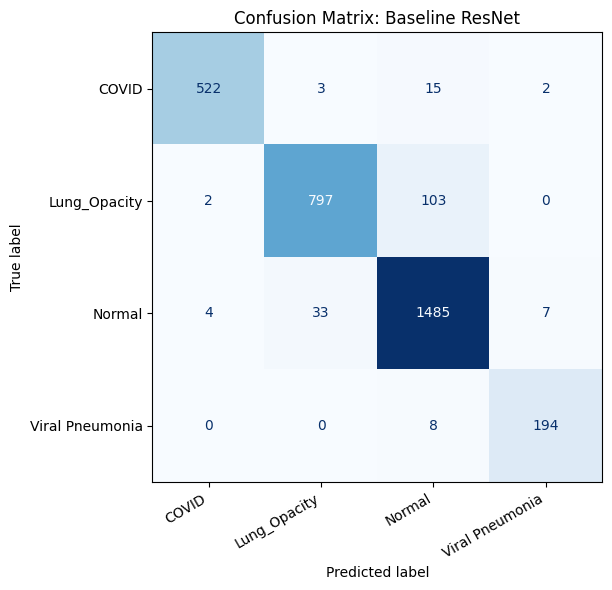

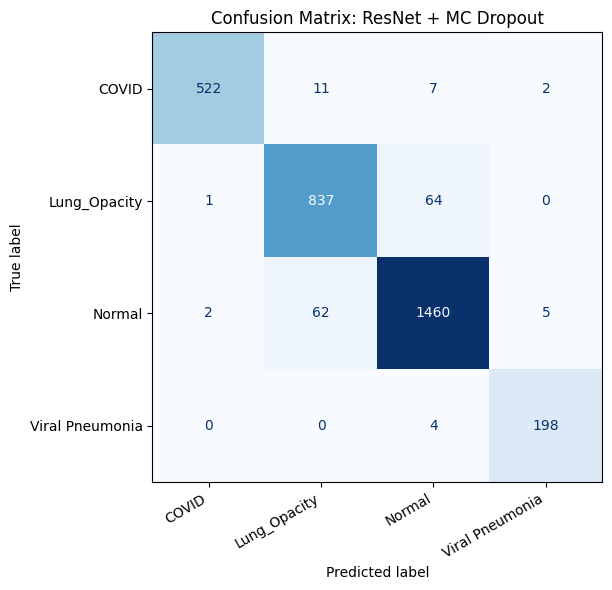

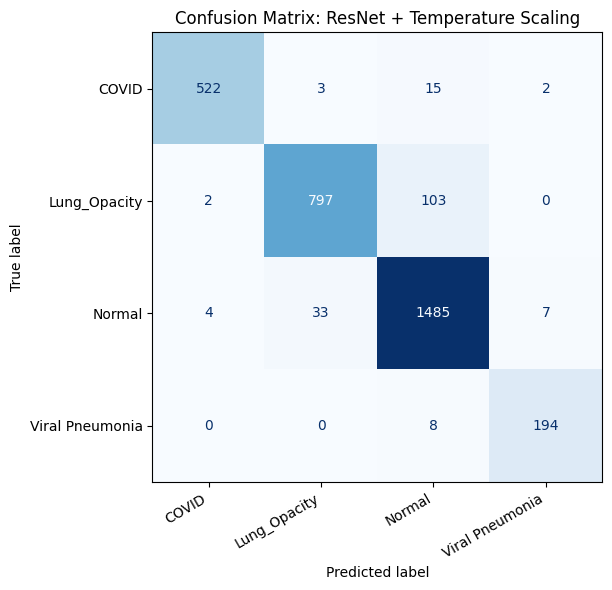

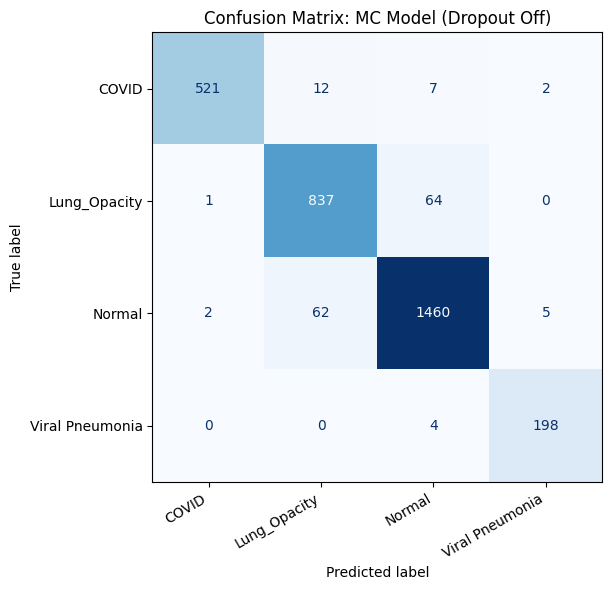

===== Main three-method metrics =====


,method,method_display,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,mean_confidence,mean_entropy,brier_score,nll,ece
0,baseline_resnet,Baseline ResNet,0.9443,0.9557,0.9446,0.9496,0.9931,0.9638,0.1025,0.0872,0.1630,0.0205
1,resnet_mc_dropout,ResNet + MC Dropout,0.9502,0.9578,0.9565,0.9571,0.9937,0.9612,0.1036,0.0797,0.1534,0.0144
2,resnet_temperature_scaling,ResNet + Temperature Scaling,0.9443,0.9557,0.9446,0.9496,0.9931,0.9527,0.1368,0.0857,0.1558,0.0101


===== MC Dropout fairness diagnostic =====


,method,method_display,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,mean_confidence,mean_entropy,brier_score,nll,ece
0,baseline_resnet,Baseline ResNet,0.9443,0.9557,0.9446,0.9496,0.9931,0.9638,0.1025,0.0872,0.1630,0.0205
1,mc_model_deterministic_control,MC Model (Dropout Off),0.9499,0.9575,0.9561,0.9567,0.9937,0.9627,0.0996,0.0797,0.1546,0.0144
2,resnet_mc_dropout,ResNet + MC Dropout,0.9502,0.9578,0.9565,0.9571,0.9937,0.9612,0.1036,0.0797,0.1534,0.0144


In [16]:
# 12. Evaluate and save final model results


# Final baseline logits on the frozen validation and test splits.
val_logits, val_labels = collect_logits_and_labels(baseline_model, val_loader, DEVICE)
test_logits, test_labels = collect_logits_and_labels(baseline_model, test_loader, DEVICE)
baseline_probs = softmax_np(test_logits)

# Temperature Scaling is fitted only on the validation split.
best_temperature, temperature_scaler = fit_temperature_scaler(val_logits, val_labels)
ts_probs = softmax_np(test_logits / best_temperature)
with open(OUTPUT_DIR / "temperature_scaling.json", "w", encoding="utf-8") as f:
    json.dump({"temperature": float(best_temperature), "fitted_on": "validation_split.csv"}, f, indent=2)

# MC Dropout predictive mean.
mc_probs, mc_labels = predict_mc_dropout_loader(
    mc_model, test_loader, n_mc=N_MC_EVAL, device=DEVICE, seed=SEED
)
assert np.array_equal(test_labels, mc_labels), "Label order mismatch between baseline and MC Dropout."

# Deterministic control for the fine-tuned MC model (Dropout switched off).
mc_det_logits, mc_det_labels = collect_logits_and_labels(mc_model, test_loader, DEVICE)
assert np.array_equal(test_labels, mc_det_labels)
mc_det_probs = softmax_np(mc_det_logits)

metrics_summary = pd.DataFrame([
    summarise_predictions(test_labels, baseline_probs, METHOD_BASELINE),
    summarise_predictions(test_labels, mc_probs, METHOD_MC),
    summarise_predictions(test_labels, ts_probs, METHOD_TS)
])
metrics_summary.to_csv(OUTPUT_DIR / "final_model_metrics_main_methods.csv", index=False)

diagnostic_metrics_summary = pd.DataFrame([
    summarise_predictions(test_labels, baseline_probs, METHOD_BASELINE),
    summarise_predictions(test_labels, mc_det_probs, METHOD_MC_DET),
    summarise_predictions(test_labels, mc_probs, METHOD_MC)
])
diagnostic_metrics_summary.to_csv(OUTPUT_DIR / "mc_dropout_fairness_diagnostic.csv", index=False)

for method, probs in [
    (METHOD_BASELINE, baseline_probs),
    (METHOD_MC, mc_probs),
    (METHOD_TS, ts_probs),
    (METHOD_MC_DET, mc_det_probs)
]:
    save_classification_outputs(test_labels, probs, method, OUTPUT_DIR)

print("===== Main three-method metrics =====")
display(metrics_summary.round(4))
print("===== MC Dropout fairness diagnostic =====")
display(diagnostic_metrics_summary.round(4))


In [17]:
# Thresholds for sample groups


HIGH_CONF_THRESHOLD = 0.90
MAX_ENTROPY = np.log(NUM_CLASSES)
UNCERTAIN_ENTROPY_THRESHOLD = 0.5 * MAX_ENTROPY

print("HIGH_CONF_THRESHOLD:", HIGH_CONF_THRESHOLD)
print("MAX_ENTROPY:", MAX_ENTROPY)
print("UNCERTAIN_ENTROPY_THRESHOLD:", UNCERTAIN_ENTROPY_THRESHOLD)


HIGH_CONF_THRESHOLD: 0.9
MAX_ENTROPY: 1.3862943611198906
UNCERTAIN_ENTROPY_THRESHOLD: 0.6931471805599453


In [18]:
# 13. Build and save final test prediction tables


baseline_result_df = build_prediction_df(test_df, test_labels, baseline_probs, METHOD_BASELINE)
mc_result_df = build_prediction_df(test_df, test_labels, mc_probs, METHOD_MC)
ts_result_df = build_prediction_df(test_df, test_labels, ts_probs, METHOD_TS)
mc_det_result_df = build_prediction_df(test_df, test_labels, mc_det_probs, METHOD_MC_DET)

all_test_results_df = pd.concat(
    [baseline_result_df, mc_result_df, ts_result_df], ignore_index=True
)
all_test_results_df.to_csv(OUTPUT_DIR / "all_test_predictions_main_methods.csv", index=False)
baseline_result_df.to_csv(OUTPUT_DIR / "baseline_final_test_predictions.csv", index=False)
mc_det_result_df.to_csv(OUTPUT_DIR / "mc_model_deterministic_test_predictions.csv", index=False)

print("Case type counts by method:")
display(pd.crosstab(all_test_results_df["method_display"], all_test_results_df["case_type"]))
baseline_result_df.head()


Case type counts by method:


case_type,Correct + high confidence,Correct but uncertain,Incorrect but uncertain,Other correct,Other incorrect,Overconfident failure
method_display,,,,,,
Baseline ResNet,2751,21,16,226,91,70
ResNet + MC Dropout,2744,23,12,250,91,55
ResNet + Temperature Scaling,2671,43,27,284,94,56


,filepath,label_name,label,dataset_index,method,method_display,true_label,pred_label,true_class,pred_class,correct,confidence,entropy,top1_top2_margin,prob_covid,prob_lung_opacity,prob_normal,prob_viral_pneumonia,case_type
0,/content/data/COVID-19_Radiography_Dataset/COV...,COVID,0,3,baseline_resnet,Baseline ResNet,0,0,COVID,COVID,True,0.999377,0.005444,0.998808,0.999377,1.606717e-05,5.684287e-04,0.000039,Correct + high confidence
1,/content/data/COVID-19_Radiography_Dataset/COV...,COVID,0,5,baseline_resnet,Baseline ResNet,0,0,COVID,COVID,True,0.998948,0.008464,0.997935,0.998948,2.252886e-05,1.012966e-03,0.000017,Correct + high confidence
2,/content/data/COVID-19_Radiography_Dataset/COV...,COVID,0,9,baseline_resnet,Baseline ResNet,0,0,COVID,COVID,True,0.999994,0.000082,0.999988,0.999994,7.220815e-08,6.656175e-08,0.000006,Correct + high confidence
3,/content/data/COVID-19_Radiography_Dataset/COV...,COVID,0,19,baseline_resnet,Baseline ResNet,0,0,COVID,COVID,True,0.951625,0.194279,0.903320,0.951625,4.830459e-02,2.646443e-05,0.000044,Correct + high confidence
4,/content/data/COVID-19_Radiography_Dataset/COV...,COVID,0,21,baseline_resnet,Baseline ResNet,0,0,COVID,COVID,True,0.999987,0.000174,0.999980,0.999987,2.872998e-06,3.556822e-06,0.000007,Correct + high confidence


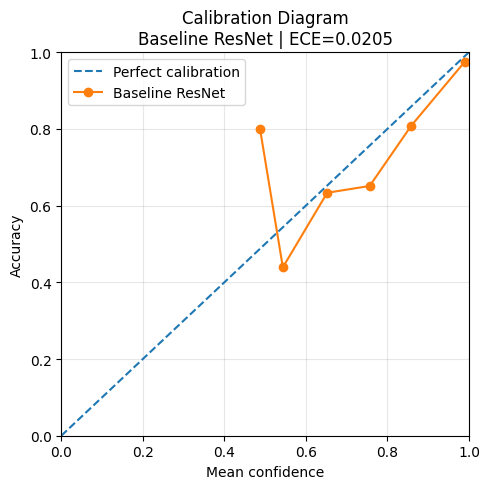

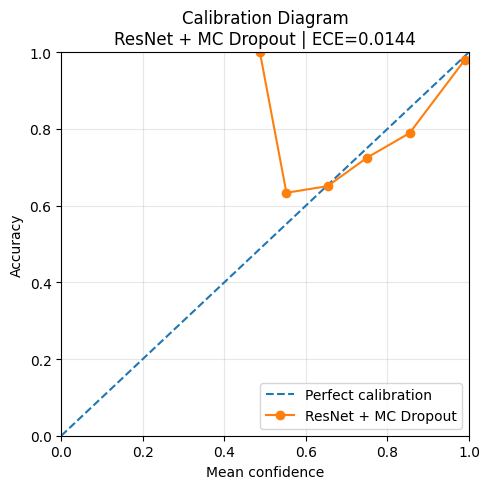

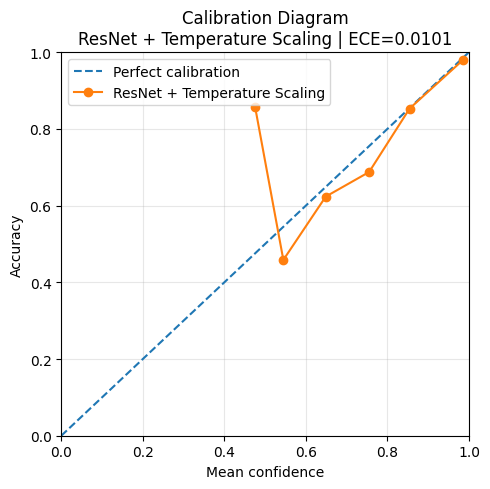

In [19]:
# 14. Calibration diagrams


def plot_calibration_diagram(y_true, probs, method, n_bins=10, save=True):
    ece, bin_df = expected_calibration_error(y_true, probs, n_bins=n_bins)

    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.plot(
        bin_df["confidence"],
        bin_df["accuracy"],
        marker="o",
        label=f"{METHOD_DISPLAY[method]}"
    )
    plt.xlabel("Mean confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Calibration Diagram\n{METHOD_DISPLAY[method]} | ECE={ece:.4f}")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save:
        safe_name = method.replace(" ", "_").replace("+", "plus")
        plt.savefig(OUTPUT_DIR / f"calibration_diagram_{safe_name}.png", dpi=300, bbox_inches="tight")
        bin_df.to_csv(OUTPUT_DIR / f"calibration_bins_{safe_name}.csv", index=False)

    plt.show()
    return bin_df


calibration_bins = {}
calibration_bins[METHOD_BASELINE] = plot_calibration_diagram(test_labels, baseline_probs, METHOD_BASELINE)
calibration_bins[METHOD_MC] = plot_calibration_diagram(test_labels, mc_probs, METHOD_MC)
calibration_bins[METHOD_TS] = plot_calibration_diagram(test_labels, ts_probs, METHOD_TS)


In [20]:
# Fixed occlusion cohort settings



FINAL_COHORT_CSV = (
    OUTPUT_DIR
    / "final_100_composite_uncertainty_samples.csv"
)

CANDIDATE_COHORT_CSV = (
    OUTPUT_DIR
    / "all_test_samples_uncertainty_ranking.csv"
)

print("TARGET_SAMPLE_COUNT:", TARGET_SAMPLE_COUNT)
print("MAX_TARGET_SAMPLES:", MAX_TARGET_SAMPLES)
print("FINAL_COHORT_CSV:", FINAL_COHORT_CSV)


TARGET_SAMPLE_COUNT: 100
MAX_TARGET_SAMPLES: None
FINAL_COHORT_CSV: /content/drive/MyDrive/PHAS0077_final_experiment/outputs_top100_composite/final_100_composite_uncertainty_samples.csv


In [21]:
# 15. Select fixed top-100 samples using composite uncertainty


def prepare_fixed_target_cohort(baseline_predictions):
    """
    Select the 100 most uncertain test images using:
    - 50% predictive entropy percentile
    - 25% inverse confidence percentile
    - 25% inverse top-1/top-2 margin percentile
    """

    required_columns = [
        "filepath",
        "dataset_index",
        "label",
        "label_name",
        "true_label",
        "true_class",
        "pred_label",
        "pred_class",
        "correct",
        "confidence",
        "entropy",
        "top1_top2_margin",
        "case_type",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in baseline_predictions.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    ranked_df = (
        baseline_predictions[required_columns]
        .drop_duplicates(subset=["filepath"])
        .copy()
        .reset_index(drop=True)
    )

    if len(ranked_df) < TARGET_SAMPLE_COUNT:
        raise ValueError(
            f"Only {len(ranked_df)} unique test images are available, "
            f"but TARGET_SAMPLE_COUNT={TARGET_SAMPLE_COUNT}."
        )

    # Higher entropy means greater uncertainty
    ranked_df["entropy_uncertainty_rank"] = (
        ranked_df["entropy"]
        .rank(method="average", pct=True)
    )

    # Lower confidence means greater uncertainty
    ranked_df["confidence_uncertainty_rank"] = (
        1.0
        - ranked_df["confidence"]
        .rank(method="average", pct=True)
    )

    # Smaller top-1/top-2 margin means greater uncertainty
    ranked_df["margin_uncertainty_rank"] = (
        1.0
        - ranked_df["top1_top2_margin"]
        .rank(method="average", pct=True)
    )

    ENTROPY_WEIGHT = 0.50
    CONFIDENCE_WEIGHT = 0.25
    MARGIN_WEIGHT = 0.25

    ranked_df["composite_uncertainty_score"] = (
        ENTROPY_WEIGHT
        * ranked_df["entropy_uncertainty_rank"]
        + CONFIDENCE_WEIGHT
        * ranked_df["confidence_uncertainty_rank"]
        + MARGIN_WEIGHT
        * ranked_df["margin_uncertainty_rank"]
    )

    ranked_df = (
        ranked_df
        .sort_values(
            by=[
                "composite_uncertainty_score",
                "entropy",
                "top1_top2_margin",
                "confidence",
                "dataset_index",
            ],
            ascending=[
                False,
                False,
                True,
                True,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    ranked_df["uncertainty_rank"] = (
        np.arange(1, len(ranked_df) + 1)
    )

    # Save the complete test-set ranking
    ranked_df.to_csv(
        CANDIDATE_COHORT_CSV,
        index=False,
    )

    # Load the already frozen top-100 cohort if it exists
    if FINAL_COHORT_CSV.exists():
        cohort = pd.read_csv(FINAL_COHORT_CSV)

        if len(cohort) != TARGET_SAMPLE_COUNT:
            raise ValueError(
                f"The saved cohort contains {len(cohort)} samples, "
                f"but TARGET_SAMPLE_COUNT={TARGET_SAMPLE_COUNT}. "
                f"Delete {FINAL_COHORT_CSV.name} and rerun this cell."
            )

        print(
            "Loaded existing fixed top-100 cohort:",
            FINAL_COHORT_CSV,
        )

    else:
        cohort = (
            ranked_df
            .head(TARGET_SAMPLE_COUNT)
            .copy()
            .reset_index(drop=True)
        )

        cohort["sample_id"] = np.arange(
            1,
            TARGET_SAMPLE_COUNT + 1,
        )

        cohort["original_threshold_case_type"] = (
            cohort["case_type"]
        )

        cohort["cohort_group"] = np.where(
            cohort["correct"],
            "Correct high-uncertainty sample",
            "Incorrect high-uncertainty sample",
        )

        # The downstream occlusion code currently reads case_type
        cohort["case_type"] = cohort["cohort_group"]

        cohort["selection_rule"] = (
            "Top 100 samples ranked by composite uncertainty: "
            "50% predictive entropy percentile, "
            "25% inverse confidence percentile, "
            "25% inverse top-1/top-2 margin percentile."
        )

        cohort.to_csv(
            FINAL_COHORT_CSV,
            index=False,
        )

        print(
            "Created and froze a top-100 composite "
            "uncertainty cohort."
        )

    cohort["sample_id"] = cohort["sample_id"].astype(int)

    cohort = (
        cohort
        .sort_values("sample_id")
        .reset_index(drop=True)
    )

    if MAX_TARGET_SAMPLES is not None:
        cohort = (
            cohort
            .head(MAX_TARGET_SAMPLES)
            .copy()
        )

    return cohort


target_sample_df = prepare_fixed_target_cohort(
    baseline_result_df
)

target_sample_df.to_csv(
    OUTPUT_DIR / "target_samples_used_in_current_run.csv",
    index=False,
)

print("\nTarget samples in this run:", len(target_sample_df))

print("\nCorrect/incorrect composition:")
print(
    target_sample_df["case_type"]
    .value_counts()
)

print("\nComposite uncertainty summary:")
print(
    target_sample_df["composite_uncertainty_score"]
    .describe()
)

print("\nOriginal uncertainty metrics:")
display(
    target_sample_df[
        [
            "entropy",
            "confidence",
            "top1_top2_margin",
            "composite_uncertainty_score",
        ]
    ].describe()
)

assert len(target_sample_df) == TARGET_SAMPLE_COUNT
assert target_sample_df["filepath"].nunique() == TARGET_SAMPLE_COUNT
assert target_sample_df["sample_id"].nunique() == TARGET_SAMPLE_COUNT

display(
    target_sample_df[
        [
            "sample_id",
            "uncertainty_rank",
            "dataset_index",
            "filepath",
            "true_class",
            "pred_class",
            "correct",
            "confidence",
            "entropy",
            "top1_top2_margin",
            "composite_uncertainty_score",
            "case_type",
        ]
    ].head(20)
)

Created and froze a top-100 composite uncertainty cohort.

Target samples in this run: 100

Correct/incorrect composition:
case_type
Correct high-uncertainty sample      60
Incorrect high-uncertainty sample    40
Name: count, dtype: int64

Composite uncertainty summary:
count    100.000000
mean       0.983570
std        0.008137
min        0.969370
25%        0.976831
50%        0.983425
75%        0.990551
max        0.997874
Name: composite_uncertainty_score, dtype: float64

Original uncertainty metrics:


,entropy,confidence,top1_top2_margin,composite_uncertainty_score
count,100.000000,100.000000,100.000000,100.000000
mean,0.720297,0.599123,0.219602,0.983570
std,0.094590,0.065858,0.140477,0.008137
min,0.633370,0.470561,0.003576,0.969370
25%,0.663627,0.544482,0.103203,0.976831
50%,0.688671,0.615821,0.234881,0.983425
75%,0.730303,0.650503,0.321483,0.990551
max,1.057031,0.750873,0.587630,0.997874


,sample_id,uncertainty_rank,dataset_index,filepath,true_class,pred_class,correct,confidence,entropy,top1_top2_margin,composite_uncertainty_score,case_type
0,1,1,4722,/content/data/COVID-19_Radiography_Dataset/Lun...,Lung_Opacity,Lung_Opacity,True,0.488759,0.932711,0.050011,0.997874,Correct high-uncertainty sample
1,2,2,1212,/content/data/COVID-19_Radiography_Dataset/COV...,COVID,COVID,True,0.470561,1.013555,0.085994,0.997795,Correct high-uncertainty sample
2,3,3,1782,/content/data/COVID-19_Radiography_Dataset/COV...,COVID,COVID,True,0.493855,0.936238,0.075208,0.997480,Correct high-uncertainty sample
3,4,4,6083,/content/data/COVID-19_Radiography_Dataset/Lun...,Lung_Opacity,Lung_Opacity,True,0.484588,0.820069,0.003576,0.997402,Correct high-uncertainty sample
4,5,5,3191,/content/data/COVID-19_Radiography_Dataset/COV...,COVID,Lung_Opacity,False,0.499342,0.806080,0.027392,0.996378,Incorrect high-uncertainty sample
5,6,6,1049,/content/data/COVID-19_Radiography_Dataset/COV...,COVID,COVID,True,0.505937,1.032132,0.135051,0.996378,Correct high-uncertainty sample
6,7,7,17601,/content/data/COVID-19_Radiography_Dataset/Nor...,Normal,Normal,True,0.522227,0.918573,0.129232,0.994882,Correct high-uncertainty sample
7,8,8,2981,/content/data/COVID-19_Radiography_Dataset/COV...,COVID,COVID,True,0.507350,0.713848,0.018126,0.994094,Correct high-uncertainty sample
8,9,9,19791,/content/data/COVID-19_Radiography_Dataset/Nor...,Normal,Normal,True,0.502969,0.693695,0.005990,0.994016,Correct high-uncertainty sample
9,10,10,7066,/content/data/COVID-19_Radiography_Dataset/Lun...,Lung_Opacity,Normal,False,0.504539,0.697340,0.009581,0.993858,Incorrect high-uncertainty sample


In [22]:
# 16. Batched 7×7 regional occlusion functions


def load_image_tensor(filepath):
    img = Image.open(filepath).convert("L")
    return img, eval_transform(img).unsqueeze(0)


def mask_grid_cell(image_tensor, row_idx, col_idx, grid_size=7, fill_value=0.0):
    masked = image_tensor.clone()
    _, _, height, width = masked.shape
    cell_h = height // grid_size
    cell_w = width // grid_size
    h1 = row_idx * cell_h
    h2 = (row_idx + 1) * cell_h if row_idx < grid_size - 1 else height
    w1 = col_idx * cell_w
    w2 = (col_idx + 1) * cell_w if col_idx < grid_size - 1 else width
    masked[:, :, h1:h2, w1:w2] = fill_value
    return masked


def build_occlusion_batch(filepath, grid_size=GRID_SIZE, fill_value=MASK_FILL_VALUE):
    _, original = load_image_tensor(filepath)
    variants = [original]
    grid_metadata = [{"variant_index": 0, "grid_row": -1, "grid_col": -1, "is_original": True}]

    variant_index = 1
    for row_idx in range(grid_size):
        for col_idx in range(grid_size):
            variants.append(mask_grid_cell(original, row_idx, col_idx, grid_size, fill_value))
            grid_metadata.append({
                "variant_index": variant_index,
                "grid_row": row_idx,
                "grid_col": col_idx,
                "is_original": False
            })
            variant_index += 1

    return torch.cat(variants, dim=0), pd.DataFrame(grid_metadata)


def summarise_prob_vector(prob):
    prob = np.asarray(prob, dtype=float)
    pred_label = int(np.argmax(prob))
    sorted_prob = np.sort(prob)
    return {
        "pred_label": pred_label,
        "pred_class": CLASS_NAMES[pred_label],
        "confidence": float(np.max(prob)),
        "entropy": float(-np.sum(prob * np.log(prob + 1e-12))),
        "top1_top2_margin": float(sorted_prob[-1] - sorted_prob[-2])
    }


def build_method_records(row, method, probs_batch, run_signature):
    original_prob = probs_batch[0]
    original = summarise_prob_vector(original_prob)
    records = []

    for variant_index in range(1, GRID_SIZE * GRID_SIZE + 1):
        grid_index = variant_index - 1
        grid_row = grid_index // GRID_SIZE
        grid_col = grid_index % GRID_SIZE
        masked_prob = probs_batch[variant_index]
        masked = summarise_prob_vector(masked_prob)

        record = {
            "run_signature": run_signature,
            "sample_id": int(row["sample_id"]),
            "dataset_index": int(row["dataset_index"]),
            "method": method,
            "method_display": METHOD_DISPLAY[method],
            "filepath": row["filepath"],
            "true_label": int(row["true_label"]),
            "true_class": row["true_class"],
            "baseline_case_type": row["case_type"],
            "seed": SEED,
            "n_mc_passes": N_MC_OCCLUSION if method == METHOD_MC else 1,
            "dropout_p": MC_DROPOUT_P if method == METHOD_MC else 0.0,
            "temperature": float(best_temperature) if method == METHOD_TS else 1.0,
            "grid_size": GRID_SIZE,
            "mask_fill_value": MASK_FILL_VALUE,
            "original_pred_label": original["pred_label"],
            "original_pred_class": original["pred_class"],
            "masked_pred_label": masked["pred_label"],
            "masked_pred_class": masked["pred_class"],
            "prediction_changed": original["pred_label"] != masked["pred_label"],
            "original_confidence": original["confidence"],
            "masked_confidence": masked["confidence"],
            "confidence_change": masked["confidence"] - original["confidence"],
            "original_entropy": original["entropy"],
            "masked_entropy": masked["entropy"],
            "entropy_change": masked["entropy"] - original["entropy"],
            "original_margin": original["top1_top2_margin"],
            "masked_margin": masked["top1_top2_margin"],
            "margin_change": masked["top1_top2_margin"] - original["top1_top2_margin"],
            "grid_row": grid_row,
            "grid_col": grid_col,
        }
        for class_idx, class_name in enumerate(CLASS_NAMES):
            safe_name = class_name.lower().replace(" ", "_")
            record[f"original_prob_{safe_name}"] = float(original_prob[class_idx])
            record[f"masked_prob_{safe_name}"] = float(masked_prob[class_idx])
        records.append(record)

    return records


def predict_all_methods_for_occlusion_batch(input_batch, sample_id):
    baseline_batch_probs, ts_batch_probs = predict_baseline_and_temperature_batch(
        input_batch, best_temperature
    )
    mc_batch_probs = predict_mc_dropout_batch(
        input_batch,
        n_mc=N_MC_OCCLUSION,
        sample_seed=SEED + int(sample_id) * 100000,
        variant_batch_size=MC_VARIANT_BATCH_SIZE
    )
    return {
        METHOD_BASELINE: baseline_batch_probs,
        METHOD_MC: mc_batch_probs,
        METHOD_TS: ts_batch_probs
    }


In [23]:
# Occlusion grid audit


print("GRID_SIZE:", GRID_SIZE)
print("Masked regions per image:", GRID_SIZE * GRID_SIZE)
print("Variants per image including original:", GRID_SIZE * GRID_SIZE + 1)


GRID_SIZE: 7
Masked regions per image: 49
Variants per image including original: 50


In [24]:
# Occlusion mask and compute audit


print("MASK_FILL_VALUE:", MASK_FILL_VALUE)
print("N_MC_OCCLUSION:", N_MC_OCCLUSION)
print("OCCLUSION_CHUNK_SIZE:", OCCLUSION_CHUNK_SIZE)
print("Expected rows for current cohort:", len(target_sample_df) * GRID_SIZE * GRID_SIZE * len(MAIN_METHODS))


MASK_FILL_VALUE: 0.0
N_MC_OCCLUSION: 30
OCCLUSION_CHUNK_SIZE: 10
Expected rows for current cohort: 14700


In [25]:
# 16B. MC Dropout stability check before the full run


def entropy_from_prob_vector(prob):
    prob = np.asarray(prob, dtype=float)
    return float(-np.sum(prob * np.log(prob + 1e-12)))


def run_mc_stability_check(target_df, n_samples=10, pass_list=MC_STABILITY_PASS_LIST):
    """
    Check whether the original predictive entropy and the top entropy-change grid
    are stable as the number of MC passes increases.
    """
    rows = []
    subset = target_df.head(min(n_samples, len(target_df))).copy()

    for _, sample_row in tqdm(subset.iterrows(), total=len(subset), desc="MC stability check"):
        input_batch, _ = build_occlusion_batch(sample_row["filepath"])
        for n_mc in pass_list:
            probs_batch = predict_mc_dropout_batch(
                input_batch,
                n_mc=n_mc,
                sample_seed=SEED + int(sample_row["sample_id"]) * 100000,
                variant_batch_size=MC_VARIANT_BATCH_SIZE
            )
            original_entropy = entropy_from_prob_vector(probs_batch[0])
            masked_entropies = np.array([
                entropy_from_prob_vector(prob) for prob in probs_batch[1:]
            ])
            entropy_changes = masked_entropies - original_entropy
            top_index = int(np.argmax(entropy_changes))
            rows.append({
                "sample_id": int(sample_row["sample_id"]),
                "n_mc_passes": int(n_mc),
                "original_pred_label": int(np.argmax(probs_batch[0])),
                "original_confidence": float(np.max(probs_batch[0])),
                "original_entropy": original_entropy,
                "top_grid_row": top_index // GRID_SIZE,
                "top_grid_col": top_index % GRID_SIZE,
                "top_entropy_change": float(entropy_changes[top_index]),
                "mean_abs_entropy_change": float(np.mean(np.abs(entropy_changes)))
            })

    stability_df = pd.DataFrame(rows)
    stability_df.to_csv(OUTPUT_DIR / "mc_dropout_stability_by_pass_count.csv", index=False)

    reference_passes = max(pass_list)
    reference = stability_df[stability_df["n_mc_passes"] == reference_passes][
        ["sample_id", "original_entropy", "top_grid_row", "top_grid_col"]
    ].rename(columns={
        "original_entropy": "reference_original_entropy",
        "top_grid_row": "reference_top_grid_row",
        "top_grid_col": "reference_top_grid_col"
    })
    comparison = stability_df.merge(reference, on="sample_id", how="left")
    comparison["abs_entropy_difference_vs_reference"] = (
        comparison["original_entropy"] - comparison["reference_original_entropy"]
    ).abs()
    comparison["top1_grid_agrees_with_reference"] = (
        (comparison["top_grid_row"] == comparison["reference_top_grid_row"]) &
        (comparison["top_grid_col"] == comparison["reference_top_grid_col"])
    )
    stability_summary = comparison.groupby("n_mc_passes").agg(
        n_samples=("sample_id", "nunique"),
        mean_abs_entropy_difference_vs_reference=("abs_entropy_difference_vs_reference", "mean"),
        top1_grid_agreement_vs_reference=("top1_grid_agrees_with_reference", "mean")
    ).reset_index()
    stability_summary.to_csv(OUTPUT_DIR / "mc_dropout_stability_summary.csv", index=False)
    return stability_df, stability_summary


if RUN_MC_STABILITY_CHECK:
    mc_stability_df, mc_stability_summary = run_mc_stability_check(
        target_sample_df,
        n_samples=MC_STABILITY_SAMPLE_COUNT,
        pass_list=MC_STABILITY_PASS_LIST
    )
    display(mc_stability_summary.round(4))
else:
    print("MC Dropout stability check skipped.")


MC stability check:   0%|          | 0/10 [00:00<?, ?it/s]

,n_mc_passes,n_samples,mean_abs_entropy_difference_vs_reference,top1_grid_agreement_vs_reference
0,10,10,0.0174,0.6
1,20,10,0.0101,0.7
2,30,10,0.0028,0.9
3,50,10,0.0000,1.0


In [26]:
# 17. Run complete 7×7 experiment with batching, checkpoints and resume


def file_sha256(path):
    path = Path(path)
    if not path.exists():
        return None
    digest = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def make_occlusion_run_signature():
    signature_payload = {
        "baseline_checkpoint_hash": file_sha256(BASELINE_CKPT),
        "mc_checkpoint_hash": file_sha256(MC_DROPOUT_CKPT),
        "test_split_hash": file_sha256(SPLIT_DIR / "test_split.csv"),
        "cohort_file_hash": file_sha256(FINAL_COHORT_CSV) or file_sha256(CANDIDATE_COHORT_CSV),
        "temperature": round(float(best_temperature), 10),
        "seed": SEED,
        "grid_size": GRID_SIZE,
        "mask_fill_value": MASK_FILL_VALUE,
        "n_mc_occlusion": N_MC_OCCLUSION,
        "dropout_p": MC_DROPOUT_P,
        "methods": MAIN_METHODS,
    }
    raw = json.dumps(signature_payload, sort_keys=True).encode("utf-8")
    return hashlib.sha256(raw).hexdigest()[:16], signature_payload


def atomic_save_csv(df, path):
    path = Path(path)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp_path, index=False)
    os.replace(tmp_path, path)


def existing_completed_sample_ids(parts_dir, run_signature):
    completed = set()
    for part_path in sorted(parts_dir.glob("occlusion_part_*.csv")):
        try:
            part = pd.read_csv(part_path, usecols=["run_signature", "sample_id"])
            part = part[part["run_signature"] == run_signature]
            completed.update(part["sample_id"].astype(int).unique().tolist())
        except Exception as exc:
            warnings.warn(f"Skipping unreadable part file {part_path}: {exc}")
    return completed


def next_part_index(parts_dir):
    indices = []
    for path in parts_dir.glob("occlusion_part_*.csv"):
        try:
            indices.append(int(path.stem.split("_")[-1]))
        except ValueError:
            pass
    return max(indices, default=-1) + 1


def run_occlusion_experiment_with_resume(target_df):
    run_signature, signature_payload = make_occlusion_run_signature()
    metadata_path = OUTPUT_DIR / "occlusion_run_metadata.json"

    if metadata_path.exists():
        previous = json.loads(metadata_path.read_text(encoding="utf-8"))
        if previous.get("run_signature") != run_signature:
            raise RuntimeError(
                "The experiment settings/checkpoints changed, but old occlusion parts still exist. "
                "Move or delete OUTPUT_DIR/occlusion_parts before starting the new final run."
            )
    else:
        metadata_path.write_text(json.dumps({
            "run_signature": run_signature,
            "settings": signature_payload
        }, indent=2), encoding="utf-8")

    completed_ids = existing_completed_sample_ids(PARTS_DIR, run_signature)
    remaining = target_df[~target_df["sample_id"].isin(completed_ids)].copy()
    print(f"Run signature: {run_signature}")
    print(f"Completed samples: {len(completed_ids)}")
    print(f"Remaining samples: {len(remaining)}")

    part_index = next_part_index(PARTS_DIR)
    chunk_records = []
    chunk_sample_count = 0

    for _, row in tqdm(remaining.iterrows(), total=len(remaining), desc="Full 7x7 occlusion"):
        input_batch, _ = build_occlusion_batch(row["filepath"])
        method_probs = predict_all_methods_for_occlusion_batch(input_batch, row["sample_id"])

        for method in MAIN_METHODS:
            chunk_records.extend(build_method_records(row, method, method_probs[method], run_signature))

        chunk_sample_count += 1
        if chunk_sample_count >= OCCLUSION_CHUNK_SIZE:
            part_df = pd.DataFrame(chunk_records)
            part_path = PARTS_DIR / f"occlusion_part_{part_index:04d}.csv"
            atomic_save_csv(part_df, part_path)
            print(f"Saved {part_path.name}: {part_df['sample_id'].nunique()} samples, {len(part_df)} rows")
            part_index += 1
            chunk_records = []
            chunk_sample_count = 0

    if chunk_records:
        part_df = pd.DataFrame(chunk_records)
        part_path = PARTS_DIR / f"occlusion_part_{part_index:04d}.csv"
        atomic_save_csv(part_df, part_path)
        print(f"Saved {part_path.name}: {part_df['sample_id'].nunique()} samples, {len(part_df)} rows")

    parts = []
    for part_path in sorted(PARTS_DIR.glob("occlusion_part_*.csv")):
        part = pd.read_csv(part_path)
        part = part[part["run_signature"] == run_signature]
        if len(part):
            parts.append(part)
    if not parts:
        raise RuntimeError("No valid occlusion part files were found.")

    regional = pd.concat(parts, ignore_index=True)
    regional = regional.drop_duplicates(
        subset=["run_signature", "sample_id", "method", "grid_row", "grid_col"],
        keep="last"
    ).sort_values(["sample_id", "method", "grid_row", "grid_col"]).reset_index(drop=True)

    expected_rows = len(target_df) * GRID_SIZE * GRID_SIZE * len(MAIN_METHODS)
    if len(regional) != expected_rows:
        warnings.warn(f"Expected {expected_rows} rows but found {len(regional)}. The run may be incomplete.")

    regional["abs_entropy_change"] = regional["entropy_change"].abs()
    regional["abs_confidence_change"] = regional["confidence_change"].abs()
    atomic_save_csv(regional, OUTPUT_DIR / "regional_occlusion_all_methods.csv")
    for method in MAIN_METHODS:
        atomic_save_csv(
            regional[regional["method"] == method].copy(),
            OUTPUT_DIR / f"regional_occlusion_{method}.csv"
        )
    return regional


if RUN_FULL_OCCLUSION:
    regional_df = run_occlusion_experiment_with_resume(target_sample_df)
else:
    regional_path = OUTPUT_DIR / "regional_occlusion_all_methods.csv"
    if not regional_path.exists():
        raise FileNotFoundError("No completed regional result exists and RUN_FULL_OCCLUSION=False.")
    regional_df = pd.read_csv(regional_path)

print("Regional occlusion rows:", len(regional_df))
display(regional_df.head())


Run signature: f22aaf9a52323235
Completed samples: 100
Remaining samples: 0


Full 7x7 occlusion: 0it [00:00, ?it/s]

Regional occlusion rows: 14700


,run_signature,sample_id,dataset_index,method,method_display,filepath,true_label,true_class,baseline_case_type,seed,...,original_prob_covid,masked_prob_covid,original_prob_lung_opacity,masked_prob_lung_opacity,original_prob_normal,masked_prob_normal,original_prob_viral_pneumonia,masked_prob_viral_pneumonia,abs_entropy_change,abs_confidence_change
0,f22aaf9a52323235,1,4722,baseline_resnet,Baseline ResNet,/content/data/COVID-19_Radiography_Dataset/Lun...,1,Lung_Opacity,Correct high-uncertainty sample,42,...,0.061342,0.331532,0.488759,0.317533,0.438748,0.331070,0.011151,0.019866,0.241399,0.157227
1,f22aaf9a52323235,1,4722,baseline_resnet,Baseline ResNet,/content/data/COVID-19_Radiography_Dataset/Lun...,1,Lung_Opacity,Correct high-uncertainty sample,42,...,0.061342,0.011760,0.488759,0.504952,0.438748,0.472801,0.011151,0.010487,0.133471,0.016193
2,f22aaf9a52323235,1,4722,baseline_resnet,Baseline ResNet,/content/data/COVID-19_Radiography_Dataset/Lun...,1,Lung_Opacity,Correct high-uncertainty sample,42,...,0.061342,0.137013,0.488759,0.425681,0.438748,0.424980,0.011151,0.012326,0.121035,0.063078
3,f22aaf9a52323235,1,4722,baseline_resnet,Baseline ResNet,/content/data/COVID-19_Radiography_Dataset/Lun...,1,Lung_Opacity,Correct high-uncertainty sample,42,...,0.061342,0.082182,0.488759,0.420023,0.438748,0.488422,0.011151,0.009372,0.030753,0.000336
4,f22aaf9a52323235,1,4722,baseline_resnet,Baseline ResNet,/content/data/COVID-19_Radiography_Dataset/Lun...,1,Lung_Opacity,Correct high-uncertainty sample,42,...,0.061342,0.063715,0.488759,0.430402,0.438748,0.499964,0.011151,0.005920,0.017489,0.011205


In [27]:
# 18. Summarise complete regional occlusion results


regional_summary = regional_df.groupby(
    ["method", "method_display", "baseline_case_type"]
).agg(
    n_samples=("sample_id", "nunique"),
    n_regions=("sample_id", "count"),
    prediction_changed_rate=("prediction_changed", "mean"),
    mean_confidence_change=("confidence_change", "mean"),
    mean_abs_confidence_change=("abs_confidence_change", "mean"),
    mean_entropy_change=("entropy_change", "mean"),
    mean_abs_entropy_change=("abs_entropy_change", "mean"),
    entropy_increase_rate=("entropy_change", lambda x: float((x > 0).mean())),
    entropy_decrease_rate=("entropy_change", lambda x: float((x < 0).mean())),
).reset_index()

regional_summary.to_csv(OUTPUT_DIR / "regional_occlusion_summary_by_method_case.csv", index=False)
display(regional_summary.round(4))


,method,method_display,baseline_case_type,n_samples,n_regions,prediction_changed_rate,mean_confidence_change,mean_abs_confidence_change,mean_entropy_change,mean_abs_entropy_change,entropy_increase_rate,entropy_decrease_rate
0,baseline_resnet,Baseline ResNet,Correct high-uncertainty sample,60,2940,0.1905,0.0253,0.0741,-0.0209,0.0646,0.4554,0.5446
1,baseline_resnet,Baseline ResNet,Incorrect high-uncertainty sample,40,1960,0.2219,0.0296,0.0711,-0.0200,0.0479,0.4408,0.5592
2,resnet_mc_dropout,ResNet + MC Dropout,Correct high-uncertainty sample,60,2940,0.0969,-0.0023,0.0558,0.0064,0.0701,0.5187,0.4813
3,resnet_mc_dropout,ResNet + MC Dropout,Incorrect high-uncertainty sample,40,1960,0.0607,-0.0080,0.0511,0.0145,0.0732,0.5367,0.4633
4,resnet_temperature_scaling,ResNet + Temperature Scaling,Correct high-uncertainty sample,60,2940,0.1905,0.0224,0.0648,-0.0142,0.0530,0.4714,0.5286
5,resnet_temperature_scaling,ResNet + Temperature Scaling,Incorrect high-uncertainty sample,40,1960,0.2219,0.0258,0.0612,-0.0124,0.0383,0.4735,0.5265


In [28]:
# 19. Three formal definitions of important regions


# A. Maximum signed entropy change: primary region for the Score-CAM comparison.
max_entropy_change_regions = (
    regional_df.sort_values("entropy_change", ascending=False)
    .groupby(["method", "sample_id"], as_index=False)
    .head(1).reset_index(drop=True)
)
max_entropy_change_regions["has_positive_entropy_increase"] = max_entropy_change_regions["entropy_change"] > 0
max_entropy_change_regions["region_definition"] = "maximum_entropy_change"
max_entropy_change_regions.to_csv(OUTPUT_DIR / "max_entropy_change_region_by_method.csv", index=False)

# B. Strongest uncertainty-reducing region.
max_entropy_decrease_regions = (
    regional_df.sort_values("entropy_change", ascending=True)
    .groupby(["method", "sample_id"], as_index=False)
    .head(1).reset_index(drop=True)
)
max_entropy_decrease_regions["region_definition"] = "maximum_entropy_decrease"
max_entropy_decrease_regions.to_csv(OUTPUT_DIR / "max_entropy_decrease_region_by_method.csv", index=False)

# C. Largest absolute change: most influential region regardless of direction.
max_absolute_change_regions = (
    regional_df.sort_values("abs_entropy_change", ascending=False)
    .groupby(["method", "sample_id"], as_index=False)
    .head(1).reset_index(drop=True)
)
max_absolute_change_regions["region_definition"] = "maximum_absolute_entropy_change"
max_absolute_change_regions.to_csv(OUTPUT_DIR / "max_absolute_entropy_change_region_by_method.csv", index=False)

sensitive_region_tables = pd.concat([
    max_entropy_change_regions,
    max_entropy_decrease_regions,
    max_absolute_change_regions
], ignore_index=True)
sensitive_region_tables.to_csv(OUTPUT_DIR / "all_sensitive_region_definitions.csv", index=False)

# Main region table used below.
top_regions = max_entropy_change_regions.copy()

print("Samples with at least one positive entropy-increase grid:")
display(
    top_regions.groupby("method_display")["has_positive_entropy_increase"]
    .agg(["sum", "count", "mean"]).round(4)
)


Samples with at least one positive entropy-increase grid:


,sum,count,mean
method_display,,,
Baseline ResNet,100,100,1.0
ResNet + MC Dropout,100,100,1.0
ResNet + Temperature Scaling,100,100,1.0


In [29]:
# 20. Automatically extract formal abnormal-case tables


# 1) Every grid where masking decreases entropy.
entropy_decrease_regions = regional_df[regional_df["entropy_change"] < 0].copy()
entropy_decrease_regions = entropy_decrease_regions.sort_values("entropy_change")
entropy_decrease_regions.to_csv(OUTPUT_DIR / "entropy_decrease_cases.csv", index=False)

# 2) Class unchanged, but confidence has one of the largest method-specific drops (bottom 5%).
confidence_drop_thresholds = (
    regional_df.groupby("method")["confidence_change"].quantile(0.05).to_dict()
)
confidence_drop_without_class_change = regional_df[
    (~regional_df["prediction_changed"]) &
    regional_df.apply(lambda r: r["confidence_change"] <= confidence_drop_thresholds[r["method"]], axis=1)
].copy()
confidence_drop_without_class_change.to_csv(
    OUTPUT_DIR / "confidence_drop_without_class_change.csv", index=False
)

# 3) Predicted class changes while entropy decreases.
class_change_with_entropy_decrease = regional_df[
    regional_df["prediction_changed"] & (regional_df["entropy_change"] < 0)
].copy()
class_change_with_entropy_decrease.to_csv(
    OUTPUT_DIR / "class_change_with_entropy_decrease.csv", index=False
)

# 4) No occluded grid produces a positive entropy increase.
no_positive_entropy_increase = top_regions[
    ~top_regions["has_positive_entropy_increase"]
].copy()
no_positive_entropy_increase.to_csv(
    OUTPUT_DIR / "samples_without_positive_entropy_increase.csv", index=False
)

abnormal_case_summary = pd.DataFrame([
    {"case": "entropy_decrease_regions", "n_rows": len(entropy_decrease_regions), "n_samples": entropy_decrease_regions["sample_id"].nunique()},
    {"case": "confidence_drop_without_class_change", "n_rows": len(confidence_drop_without_class_change), "n_samples": confidence_drop_without_class_change["sample_id"].nunique()},
    {"case": "class_change_with_entropy_decrease", "n_rows": len(class_change_with_entropy_decrease), "n_samples": class_change_with_entropy_decrease["sample_id"].nunique()},
    {"case": "no_positive_entropy_increase", "n_rows": len(no_positive_entropy_increase), "n_samples": no_positive_entropy_increase["sample_id"].nunique()},
])
abnormal_case_summary.to_csv(OUTPUT_DIR / "abnormal_case_summary.csv", index=False)
display(abnormal_case_summary)


,case,n_rows,n_samples
0,entropy_decrease_regions,7606,100
1,confidence_drop_without_class_change,510,79
2,class_change_with_entropy_decrease,1247,89
3,no_positive_entropy_increase,0,0


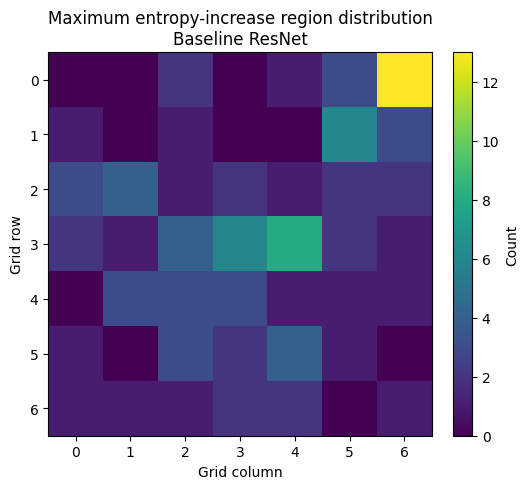

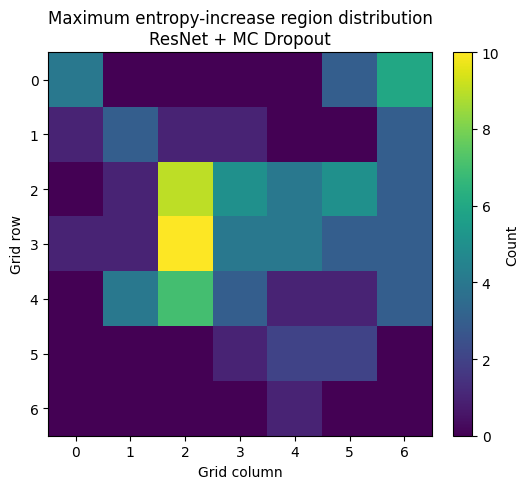

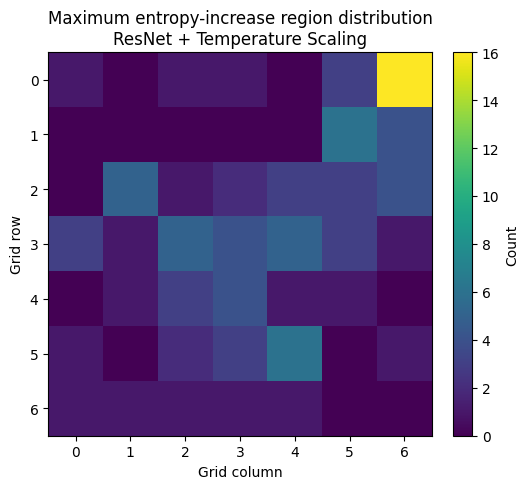

In [30]:
# 21. Distribution of maximum entropy-increase regions over the 7×7 grid


positive_top_regions = top_regions[top_regions["has_positive_entropy_increase"]].copy()
grid_distribution = (
    positive_top_regions.groupby(["method", "method_display", "grid_row", "grid_col"])
    .size().reset_index(name="count")
)
grid_distribution.to_csv(OUTPUT_DIR / "positive_entropy_increase_grid_distribution.csv", index=False)


def plot_grid_distribution(method, save=True):
    one = grid_distribution[grid_distribution["method"] == method]
    grid = np.zeros((GRID_SIZE, GRID_SIZE))
    for _, row in one.iterrows():
        grid[int(row["grid_row"]), int(row["grid_col"])] = row["count"]

    plt.figure(figsize=(6, 5))
    im = plt.imshow(grid)
    plt.title(f"Maximum entropy-increase region distribution\n{METHOD_DISPLAY[method]}")
    plt.xlabel("Grid column")
    plt.ylabel("Grid row")
    plt.colorbar(im, fraction=0.046, pad=0.04, label="Count")
    plt.tight_layout()
    if save:
        plt.savefig(OUTPUT_DIR / f"positive_grid_distribution_{method}.png", dpi=300, bbox_inches="tight")
    plt.show()


for method in MAIN_METHODS:
    plot_grid_distribution(method)


In [31]:
# 22. Vectorised baseline Score-CAM implementation


class BatchedScoreCAM:
    def __init__(self, model, target_layer, device):
        self.model = model
        self.target_layer = target_layer
        self.device = device
        self.activations = None
        self.hook = self.target_layer.register_forward_hook(self._save_activation)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()

    @torch.no_grad()
    def generate(self, input_tensor, target_class=None, max_channels=64, channel_batch_size=16):
        self.model.eval()
        input_tensor = input_tensor.to(self.device)

        logits = self.model(input_tensor)
        probs = F.softmax(logits, dim=1)
        if target_class is None:
            target_class = int(probs.argmax(dim=1).item())

        original_activations = self.activations.clone()
        activations = F.relu(original_activations[:, :min(original_activations.size(1), max_channels)])
        n_channels = activations.size(1)

        flat = activations.view(1, n_channels, -1)
        mins = flat.min(dim=2).values.view(1, n_channels, 1, 1)
        maxs = flat.max(dim=2).values.view(1, n_channels, 1, 1)
        valid = (maxs - mins).view(-1) > 1e-8
        norm = (activations - mins) / (maxs - mins + 1e-8)
        norm = norm[:, valid]
        low_res_maps = activations[:, valid]

        if norm.size(1) == 0:
            return np.zeros(input_tensor.shape[-2:], dtype=np.float32)

        up = F.interpolate(norm, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        masked_inputs = input_tensor * up.squeeze(0).unsqueeze(1)

        weights = []
        for start in range(0, masked_inputs.size(0), channel_batch_size):
            batch = masked_inputs[start:start + channel_batch_size]
            batch_probs = F.softmax(self.model(batch), dim=1)
            weights.append(batch_probs[:, target_class].detach())
        weights = torch.cat(weights).view(1, -1, 1, 1)

        scorecam_low = F.relu((weights * low_res_maps).sum(dim=1, keepdim=True))
        scorecam = F.interpolate(scorecam_low, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = scorecam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam

    def remove_hooks(self):
        self.hook.remove()


scorecam_baseline = BatchedScoreCAM(baseline_model, baseline_model.layer4[-1], DEVICE)


def scorecam_to_grid(cam, grid_size=GRID_SIZE):
    height, width = cam.shape
    grid_values = np.zeros((grid_size, grid_size), dtype=float)
    for row_idx in range(grid_size):
        for col_idx in range(grid_size):
            y1 = int(row_idx * height / grid_size)
            y2 = int((row_idx + 1) * height / grid_size) if row_idx < grid_size - 1 else height
            x1 = int(col_idx * width / grid_size)
            x2 = int((col_idx + 1) * width / grid_size) if col_idx < grid_size - 1 else width
            grid_values[row_idx, col_idx] = float(cam[y1:y2, x1:x2].mean())
    return grid_values


In [32]:
# Score-CAM overlap audit


print("RUN_SCORECAM_OVERLAP:", RUN_SCORECAM_OVERLAP)
print("SCORECAM_TOP_K:", SCORECAM_TOP_K)
print("UQ_TOP_K:", UQ_TOP_K)
print("Main comparison uses one fixed Baseline Score-CAM map for all three UQ methods.")


RUN_SCORECAM_OVERLAP: True
SCORECAM_TOP_K: 5
UQ_TOP_K: 5
Main comparison uses one fixed Baseline Score-CAM map for all three UQ methods.


In [33]:
# 23. Formal Score-CAM vs UQ overlap: Hit@5 and IoU@5


def next_scorecam_part_index():
    indices = []
    for path in SCORECAM_PARTS_DIR.glob("scorecam_part_*.csv"):
        try:
            indices.append(int(path.stem.split("_")[-1]))
        except ValueError:
            pass
    return max(indices, default=-1) + 1


def load_completed_scorecam_ids():
    completed = set()
    for path in SCORECAM_PARTS_DIR.glob("scorecam_part_*.csv"):
        try:
            part = pd.read_csv(path, usecols=["sample_id"])
            completed.update(part["sample_id"].astype(int).unique())
        except Exception as exc:
            warnings.warn(f"Could not read {path}: {exc}")
    return completed


def make_scorecam_run_signature():
    payload = {
        "baseline_checkpoint_hash": file_sha256(BASELINE_CKPT),
        "cohort_file_hash": file_sha256(FINAL_COHORT_CSV) or file_sha256(CANDIDATE_COHORT_CSV),
        "scorecam_max_channels": SCORECAM_MAX_CHANNELS,
        "scorecam_channel_batch_size": SCORECAM_CHANNEL_BATCH_SIZE,
        "grid_size": GRID_SIZE,
        "seed": SEED,
    }
    raw = json.dumps(payload, sort_keys=True).encode("utf-8")
    return hashlib.sha256(raw).hexdigest()[:16], payload


def run_scorecam_grid_with_resume(target_df):
    scorecam_signature, scorecam_payload = make_scorecam_run_signature()
    metadata_path = OUTPUT_DIR / "scorecam_run_metadata.json"
    if metadata_path.exists():
        previous = json.loads(metadata_path.read_text(encoding="utf-8"))
        if previous.get("run_signature") != scorecam_signature:
            raise RuntimeError(
                "Score-CAM settings/checkpoint changed while old scorecam_parts exist. "
                "Move or delete OUTPUT_DIR/scorecam_parts before rerunning."
            )
    else:
        metadata_path.write_text(json.dumps({
            "run_signature": scorecam_signature,
            "settings": scorecam_payload
        }, indent=2), encoding="utf-8")

    completed = load_completed_scorecam_ids()
    remaining = target_df[~target_df["sample_id"].isin(completed)].copy()
    part_index = next_scorecam_part_index()
    records = []
    sample_count = 0

    for _, row in tqdm(remaining.iterrows(), total=len(remaining), desc="Baseline Score-CAM"):
        _, input_tensor = load_image_tensor(row["filepath"])
        target_class = int(row["pred_label"])
        cam = scorecam_baseline.generate(
            input_tensor,
            target_class=target_class,
            max_channels=SCORECAM_MAX_CHANNELS,
            channel_batch_size=SCORECAM_CHANNEL_BATCH_SIZE
        )
        grid = scorecam_to_grid(cam)
        for grid_row in range(GRID_SIZE):
            for grid_col in range(GRID_SIZE):
                records.append({
                    "sample_id": int(row["sample_id"]),
                    "dataset_index": int(row["dataset_index"]),
                    "filepath": row["filepath"],
                    "true_class": row["true_class"],
                    "baseline_case_type": row["case_type"],
                    "baseline_pred_label": target_class,
                    "baseline_pred_class": CLASS_NAMES[target_class],
                    "grid_row": grid_row,
                    "grid_col": grid_col,
                    "scorecam_value": float(grid[grid_row, grid_col])
                })
        sample_count += 1
        if sample_count >= SCORECAM_CHUNK_SIZE:
            part_df = pd.DataFrame(records)
            atomic_save_csv(part_df, SCORECAM_PARTS_DIR / f"scorecam_part_{part_index:04d}.csv")
            part_index += 1
            records, sample_count = [], 0

    if records:
        atomic_save_csv(pd.DataFrame(records), SCORECAM_PARTS_DIR / f"scorecam_part_{part_index:04d}.csv")

    parts = [pd.read_csv(path) for path in sorted(SCORECAM_PARTS_DIR.glob("scorecam_part_*.csv"))]
    if not parts:
        raise RuntimeError("No Score-CAM part files were produced.")
    scorecam_grid_df = pd.concat(parts, ignore_index=True).drop_duplicates(
        subset=["sample_id", "grid_row", "grid_col"], keep="last"
    )
    scorecam_grid_df = scorecam_grid_df.sort_values(["sample_id", "grid_row", "grid_col"]).reset_index(drop=True)
    atomic_save_csv(scorecam_grid_df, OUTPUT_DIR / "scorecam_7x7_values.csv")
    return scorecam_grid_df


def top_k_grid_set(df, value_col, k, ascending=False):
    ranked = df.sort_values(value_col, ascending=ascending).head(k)
    return {(int(r), int(c)) for r, c in zip(ranked["grid_row"], ranked["grid_col"])}


def spearman_from_grid_values(x, y):
    x_rank = pd.Series(x).rank(method="average").to_numpy()
    y_rank = pd.Series(y).rank(method="average").to_numpy()
    if np.std(x_rank) == 0 or np.std(y_rank) == 0:
        return np.nan
    return float(np.corrcoef(x_rank, y_rank)[0, 1])


def build_overlap_table(scorecam_grid_df, regional_df):
    records = []
    for sample_id in tqdm(sorted(regional_df["sample_id"].unique()), desc="Overlap metrics"):
        cam_one = scorecam_grid_df[scorecam_grid_df["sample_id"] == sample_id].copy()
        if len(cam_one) != GRID_SIZE * GRID_SIZE:
            warnings.warn(f"Sample {sample_id} has {len(cam_one)} Score-CAM cells, expected 49.")
            continue
        cam_top = top_k_grid_set(cam_one, "scorecam_value", SCORECAM_TOP_K, ascending=False)
        cam_top1 = next(iter(top_k_grid_set(cam_one, "scorecam_value", 1, ascending=False)))

        for method in MAIN_METHODS:
            uq_one = regional_df[(regional_df["sample_id"] == sample_id) & (regional_df["method"] == method)].copy()
            if len(uq_one) != GRID_SIZE * GRID_SIZE:
                continue
            uq_top = top_k_grid_set(uq_one, "entropy_change", UQ_TOP_K, ascending=False)
            uq_top1 = next(iter(top_k_grid_set(uq_one, "entropy_change", 1, ascending=False)))
            intersection = len(cam_top & uq_top)
            union = len(cam_top | uq_top)
            top1_row = uq_one.sort_values("entropy_change", ascending=False).iloc[0]
            cam_ordered = cam_one.sort_values(["grid_row", "grid_col"])
            uq_ordered = uq_one.sort_values(["grid_row", "grid_col"])

            records.append({
                "sample_id": int(sample_id),
                "method": method,
                "method_display": METHOD_DISPLAY[method],
                "true_class": top1_row["true_class"],
                "baseline_case_type": top1_row["baseline_case_type"],
                "prediction_changed_at_uq_top1": bool(top1_row["prediction_changed"]),
                "uq_top1_grid_row": uq_top1[0],
                "uq_top1_grid_col": uq_top1[1],
                "cam_top1_grid_row": cam_top1[0],
                "cam_top1_grid_col": cam_top1[1],
                "top1_exact_match": uq_top1 == cam_top1,
                "top1_manhattan_distance": abs(uq_top1[0] - cam_top1[0]) + abs(uq_top1[1] - cam_top1[1]),
                "hit_at_5": uq_top1 in cam_top,
                "intersection_at_5": intersection,
                "iou_at_5": intersection / union if union else np.nan,
                "has_positive_entropy_increase": float(top1_row["entropy_change"]) > 0,
                "top1_entropy_change": float(top1_row["entropy_change"]),
                "grid_rank_spearman": spearman_from_grid_values(
                    cam_ordered["scorecam_value"].to_numpy(),
                    uq_ordered["entropy_change"].to_numpy()
                )
            })
    return pd.DataFrame(records)


if RUN_SCORECAM_OVERLAP:
    scorecam_grid_df = run_scorecam_grid_with_resume(target_sample_df)
    overlap_df = build_overlap_table(scorecam_grid_df, regional_df)
    overlap_df.to_csv(OUTPUT_DIR / "scorecam_uq_overlap_per_sample.csv", index=False)

    overlap_summary = overlap_df.groupby(
        ["method", "method_display", "baseline_case_type"]
    ).agg(
        n_samples=("sample_id", "nunique"),
        hit_rate_at_5=("hit_at_5", "mean"),
        mean_iou_at_5=("iou_at_5", "mean"),
        median_iou_at_5=("iou_at_5", "median"),
        top1_exact_match_rate=("top1_exact_match", "mean"),
        mean_top1_distance=("top1_manhattan_distance", "mean"),
        mean_grid_rank_spearman=("grid_rank_spearman", "mean"),
        positive_entropy_increase_rate=("has_positive_entropy_increase", "mean")
    ).reset_index()
    overlap_summary.to_csv(OUTPUT_DIR / "scorecam_uq_overlap_summary.csv", index=False)

    zero_overlap_cases = overlap_df[(~overlap_df["hit_at_5"]) & (overlap_df["iou_at_5"] == 0)].copy()
    zero_overlap_cases.to_csv(OUTPUT_DIR / "scorecam_uq_zero_overlap_cases.csv", index=False)

    # Samples where Baseline and TS agree on top-1 but MC Dropout selects another grid.
    pivot = overlap_df.pivot_table(
        index="sample_id", columns="method",
        values=["uq_top1_grid_row", "uq_top1_grid_col"], aggfunc="first"
    )
    disagreement_ids = []
    for sample_id, row in pivot.iterrows():
        try:
            b = (int(row[("uq_top1_grid_row", METHOD_BASELINE)]), int(row[("uq_top1_grid_col", METHOD_BASELINE)]))
            t = (int(row[("uq_top1_grid_row", METHOD_TS)]), int(row[("uq_top1_grid_col", METHOD_TS)]))
            m = (int(row[("uq_top1_grid_row", METHOD_MC)]), int(row[("uq_top1_grid_col", METHOD_MC)]))
            if b == t and m != b:
                disagreement_ids.append(int(sample_id))
        except Exception:
            continue
    mc_disagreement_cases = overlap_df[overlap_df["sample_id"].isin(disagreement_ids)].copy()
    mc_disagreement_cases.to_csv(OUTPUT_DIR / "mc_dropout_spatial_disagreement_cases.csv", index=False)

    display(overlap_summary.round(4))
else:
    overlap_df = pd.DataFrame()
    overlap_summary = pd.DataFrame()
    print("Score-CAM overlap analysis skipped.")


Baseline Score-CAM: 0it [00:00, ?it/s]

Overlap metrics:   0%|          | 0/100 [00:00<?, ?it/s]

,method,method_display,baseline_case_type,n_samples,hit_rate_at_5,mean_iou_at_5,median_iou_at_5,top1_exact_match_rate,mean_top1_distance,mean_grid_rank_spearman,positive_entropy_increase_rate
0,baseline_resnet,Baseline ResNet,Correct high-uncertainty sample,60,0.4500,0.1644,0.1111,0.1333,2.7667,0.0625,1.0
1,baseline_resnet,Baseline ResNet,Incorrect high-uncertainty sample,40,0.3750,0.1301,0.1111,0.1000,3.4500,0.0379,1.0
2,resnet_mc_dropout,ResNet + MC Dropout,Correct high-uncertainty sample,60,0.3167,0.1151,0.1111,0.0833,3.2333,0.0617,1.0
3,resnet_mc_dropout,ResNet + MC Dropout,Incorrect high-uncertainty sample,40,0.1500,0.1272,0.0000,0.0250,3.4500,0.0403,1.0
4,resnet_temperature_scaling,ResNet + Temperature Scaling,Correct high-uncertainty sample,60,0.4167,0.1736,0.1111,0.1333,2.9000,0.0897,1.0
5,resnet_temperature_scaling,ResNet + Temperature Scaling,Incorrect high-uncertainty sample,40,0.4250,0.1542,0.1111,0.1250,3.3750,0.0921,1.0


In [34]:
# 24. Visualisation helpers for report figures


import matplotlib.patches as patches


def plot_regional_entropy_map(sample_id, method, save=True):
    one = regional_df[(regional_df["sample_id"] == sample_id) & (regional_df["method"] == method)].copy()
    if len(one) == 0:
        raise ValueError("No regional result found for this sample and method.")

    original_img = Image.open(one["filepath"].iloc[0]).convert("L")
    entropy_map = np.zeros((GRID_SIZE, GRID_SIZE))
    for _, row in one.iterrows():
        entropy_map[int(row["grid_row"]), int(row["grid_col"])] = row["entropy_change"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(original_img, cmap="gray")
    axes[0].set_title("Original image")
    axes[0].axis("off")
    max_abs = np.max(np.abs(entropy_map)) + 1e-8
    im = axes[1].imshow(entropy_map, vmin=-max_abs, vmax=max_abs, cmap="coolwarm")
    axes[1].set_title(f"Signed entropy change\n{METHOD_DISPLAY[method]}")
    axes[1].set_xlabel("Grid column")
    axes[1].set_ylabel("Grid row")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    if save:
        plt.savefig(OUTPUT_DIR / f"sample_{sample_id}_{method}_entropy_map.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_scorecam_and_three_uq_methods(sample_id, save=True):
    if not RUN_SCORECAM_OVERLAP:
        raise ValueError("Run Score-CAM overlap first.")

    sample_row = target_sample_df[target_sample_df["sample_id"] == sample_id]
    if len(sample_row) == 0:
        raise ValueError("Unknown sample_id.")
    sample_row = sample_row.iloc[0]
    original_img = Image.open(sample_row["filepath"]).convert("L")
    _, input_tensor = load_image_tensor(sample_row["filepath"])
    cam = scorecam_baseline.generate(
        input_tensor,
        target_class=int(sample_row["pred_label"]),
        max_channels=SCORECAM_MAX_CHANNELS,
        channel_batch_size=SCORECAM_CHANNEL_BATCH_SIZE
    )
    cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize(original_img.size)
    cam_resized = np.asarray(cam_img, dtype=float) / 255.0

    fig, axes = plt.subplots(1, 5, figsize=(21, 4.5))
    axes[0].imshow(original_img, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(original_img, cmap="gray")
    axes[1].imshow(cam_resized, alpha=0.45, cmap="jet")
    axes[1].set_title("Baseline Score-CAM")
    axes[1].axis("off")

    img_w, img_h = original_img.size
    cell_w, cell_h = img_w / GRID_SIZE, img_h / GRID_SIZE
    for axis, method in zip(axes[2:], MAIN_METHODS):
        one = top_regions[(top_regions["sample_id"] == sample_id) & (top_regions["method"] == method)]
        if len(one) == 0:
            axis.axis("off")
            continue
        row = one.iloc[0]
        axis.imshow(original_img, cmap="gray")
        axis.imshow(cam_resized, alpha=0.30, cmap="jet")
        rect = patches.Rectangle(
            (int(row["grid_col"]) * cell_w, int(row["grid_row"]) * cell_h),
            cell_w, cell_h, linewidth=3, edgecolor="red", facecolor="none"
        )
        axis.add_patch(rect)
        axis.set_title(f"{METHOD_DISPLAY[method]}\nΔH={row['entropy_change']:.3f}")
        axis.axis("off")

    plt.suptitle(
        f"Sample {sample_id} | True: {sample_row['true_class']} | "
        f"Baseline prediction: {sample_row['pred_class']}"
    )
    plt.tight_layout()
    if save:
        plt.savefig(OUTPUT_DIR / f"sample_{sample_id}_scorecam_three_uq_methods.png", dpi=300, bbox_inches="tight")
    plt.show()


# Example:
# plot_regional_entropy_map(sample_id=1, method=METHOD_BASELINE)
# plot_scorecam_and_three_uq_methods(sample_id=1)


In [35]:
# 25. Final report tables and automatic research-story summary


main_occlusion_summary = regional_df.groupby(["method", "method_display"]).agg(
    n_samples=("sample_id", "nunique"),
    prediction_changed_rate=("prediction_changed", "mean"),
    mean_confidence_change=("confidence_change", "mean"),
    mean_entropy_change=("entropy_change", "mean"),
    mean_abs_entropy_change=("abs_entropy_change", "mean"),
    entropy_increase_rate=("entropy_change", lambda x: float((x > 0).mean())),
    entropy_decrease_rate=("entropy_change", lambda x: float((x < 0).mean()))
).reset_index()
main_occlusion_summary.to_csv(OUTPUT_DIR / "final_occlusion_summary.csv", index=False)

report_summary = metrics_summary.merge(
    main_occlusion_summary,
    on=["method", "method_display"],
    how="left"
)

if RUN_SCORECAM_OVERLAP and len(overlap_summary):
    overlap_overall = overlap_df.groupby(["method", "method_display"]).agg(
        hit_rate_at_5=("hit_at_5", "mean"),
        mean_iou_at_5=("iou_at_5", "mean"),
        top1_exact_match_rate=("top1_exact_match", "mean"),
        mean_top1_distance=("top1_manhattan_distance", "mean"),
        mean_grid_rank_spearman=("grid_rank_spearman", "mean")
    ).reset_index()
    report_summary = report_summary.merge(overlap_overall, on=["method", "method_display"], how="left")

report_summary.to_csv(OUTPUT_DIR / "final_report_summary_table.csv", index=False)

# Create a cautious, data-driven stage summary for the report-writing step.
metric_lookup = report_summary.set_index("method").to_dict(orient="index")
lines = [
    "# Stage research story (automatically generated)",
    "",
    f"The final experiment used a frozen ResNet-18 baseline, a frozen test split, and {len(target_sample_df)} target images.",
    f"Each image was evaluated using a {GRID_SIZE}×{GRID_SIZE} occlusion grid under Baseline, MC Dropout, and Temperature Scaling.",
    "",
    "## Overall model behaviour",
]
for method in MAIN_METHODS:
    m = metric_lookup[method]
    lines.append(
        f"- {METHOD_DISPLAY[method]}: Accuracy={m['accuracy']:.4f}, Macro-F1={m['f1_macro']:.4f}, "
        f"AUC={m['auc_macro_ovr']:.4f}, ECE={m['ece']:.4f}, NLL={m['nll']:.4f}."
    )
lines.extend(["", "## Regional occlusion behaviour"])
for method in MAIN_METHODS:
    m = metric_lookup[method]
    lines.append(
        f"- {METHOD_DISPLAY[method]}: class-change rate={m['prediction_changed_rate']:.4f}, "
        f"mean entropy change={m['mean_entropy_change']:.4f}, "
        f"entropy-increase rate={m['entropy_increase_rate']:.4f}."
    )
if RUN_SCORECAM_OVERLAP and "hit_rate_at_5" in report_summary.columns:
    lines.extend(["", "## Score-CAM and uncertainty-region agreement"])
    for method in MAIN_METHODS:
        m = metric_lookup[method]
        lines.append(
            f"- {METHOD_DISPLAY[method]}: Hit@5={m.get('hit_rate_at_5', np.nan):.4f}, "
            f"mean IoU@5={m.get('mean_iou_at_5', np.nan):.4f}."
        )
lines.extend([
    "",
    "## Discussion focus",
    "The final interpretation should distinguish classification performance, probability calibration, and spatial uncertainty sensitivity.",
    "Entropy-decrease cases, class changes accompanied by lower entropy, zero CAM-UQ overlap, and MC Dropout spatial disagreements are retained as formal discussion cases rather than discarded as noise."
])
(OUTPUT_DIR / "stage_research_story.md").write_text("\n".join(lines), encoding="utf-8")

print("===== Final report summary =====")
display(report_summary.round(4))
print("===== Abnormal case summary =====")
display(abnormal_case_summary)


===== Final report summary =====


,method,method_display,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,mean_confidence,mean_entropy,brier_score,...,mean_confidence_change,mean_entropy_change,mean_abs_entropy_change,entropy_increase_rate,entropy_decrease_rate,hit_rate_at_5,mean_iou_at_5,top1_exact_match_rate,mean_top1_distance,mean_grid_rank_spearman
0,baseline_resnet,Baseline ResNet,0.9443,0.9557,0.9446,0.9496,0.9931,0.9638,0.1025,0.0872,...,0.0270,-0.0206,0.0579,0.4496,0.5504,0.42,0.1506,0.12,3.04,0.0527
1,resnet_mc_dropout,ResNet + MC Dropout,0.9502,0.9578,0.9565,0.9571,0.9937,0.9612,0.1036,0.0797,...,-0.0046,0.0097,0.0713,0.5259,0.4741,0.25,0.1199,0.06,3.32,0.0531
2,resnet_temperature_scaling,ResNet + Temperature Scaling,0.9443,0.9557,0.9446,0.9496,0.9931,0.9527,0.1368,0.0857,...,0.0238,-0.0135,0.0471,0.4722,0.5278,0.42,0.1658,0.13,3.09,0.0906


===== Abnormal case summary =====


,case,n_rows,n_samples
0,entropy_decrease_regions,7606,100
1,confidence_drop_without_class_change,510,79
2,class_change_with_entropy_decrease,1247,89
3,no_positive_entropy_increase,0,0


In [36]:
# 26. Final output audit


print("OUTPUT_DIR =", OUTPUT_DIR)
print("\nGenerated files:")
for file_path in sorted(OUTPUT_DIR.rglob("*")):
    if file_path.is_file():
        print(file_path.relative_to(OUTPUT_DIR))

required_outputs = [
    OUTPUT_DIR / "final_model_metrics_main_methods.csv",
    OUTPUT_DIR / "baseline_final_test_predictions.csv",
    OUTPUT_DIR / "regional_occlusion_all_methods.csv",
    OUTPUT_DIR / "final_occlusion_summary.csv",
    OUTPUT_DIR / "abnormal_case_summary.csv",
    OUTPUT_DIR / "final_report_summary_table.csv",
    OUTPUT_DIR / "stage_research_story.md",
]
if RUN_SCORECAM_OVERLAP:
    required_outputs += [
        OUTPUT_DIR / "scorecam_7x7_values.csv",
        OUTPUT_DIR / "scorecam_uq_overlap_per_sample.csv",
        OUTPUT_DIR / "scorecam_uq_overlap_summary.csv",
    ]

missing = [str(path) for path in required_outputs if not path.exists()]
if missing:
    print("\nMissing outputs (the corresponding cells may still need to run):")
    for path in missing:
        print("-", path)
else:
    print("\nAll required final outputs are present.")


OUTPUT_DIR = /content/drive/MyDrive/PHAS0077_final_experiment/outputs_top100_composite

Generated files:
PHAS0077_representative_examples.zip
abnormal_case_summary.csv
all_sensitive_region_definitions.csv
all_test_predictions_main_methods.csv
all_test_samples_uncertainty_ranking.csv
baseline_final_test_predictions.csv
calibration_bins_baseline_resnet.csv
calibration_bins_resnet_mc_dropout.csv
calibration_bins_resnet_temperature_scaling.csv
calibration_diagram_baseline_resnet.png
calibration_diagram_resnet_mc_dropout.png
calibration_diagram_resnet_temperature_scaling.png
class_change_with_entropy_decrease.csv
classification_report_baseline_resnet.csv
classification_report_mc_model_deterministic_control.csv
classification_report_resnet_mc_dropout.csv
classification_report_resnet_temperature_scaling.csv
confidence_drop_without_class_change.csv
confusion_matrix_baseline_resnet.csv
confusion_matrix_baseline_resnet.png
confusion_matrix_mc_model_deterministic_control.csv
confusion_matrix_mc_m